# Introduction

Reinforcement Learning Trees (RLT) are an advanced variation of the standard Random Forest algorithm designed to handle high-dimensional data, strong feature correlations, and complex interaction effects.<br>
Unlike a standard Random Forest, which selects splitting variables purely at random (or greedily), RLT employs a "Reinforcement" mechanism. It uses an internal embedded model to learn variable importance at each node, allowing it to intelligently "mute" dominant variables and expose hidden relationships.

#### Example of one tree :

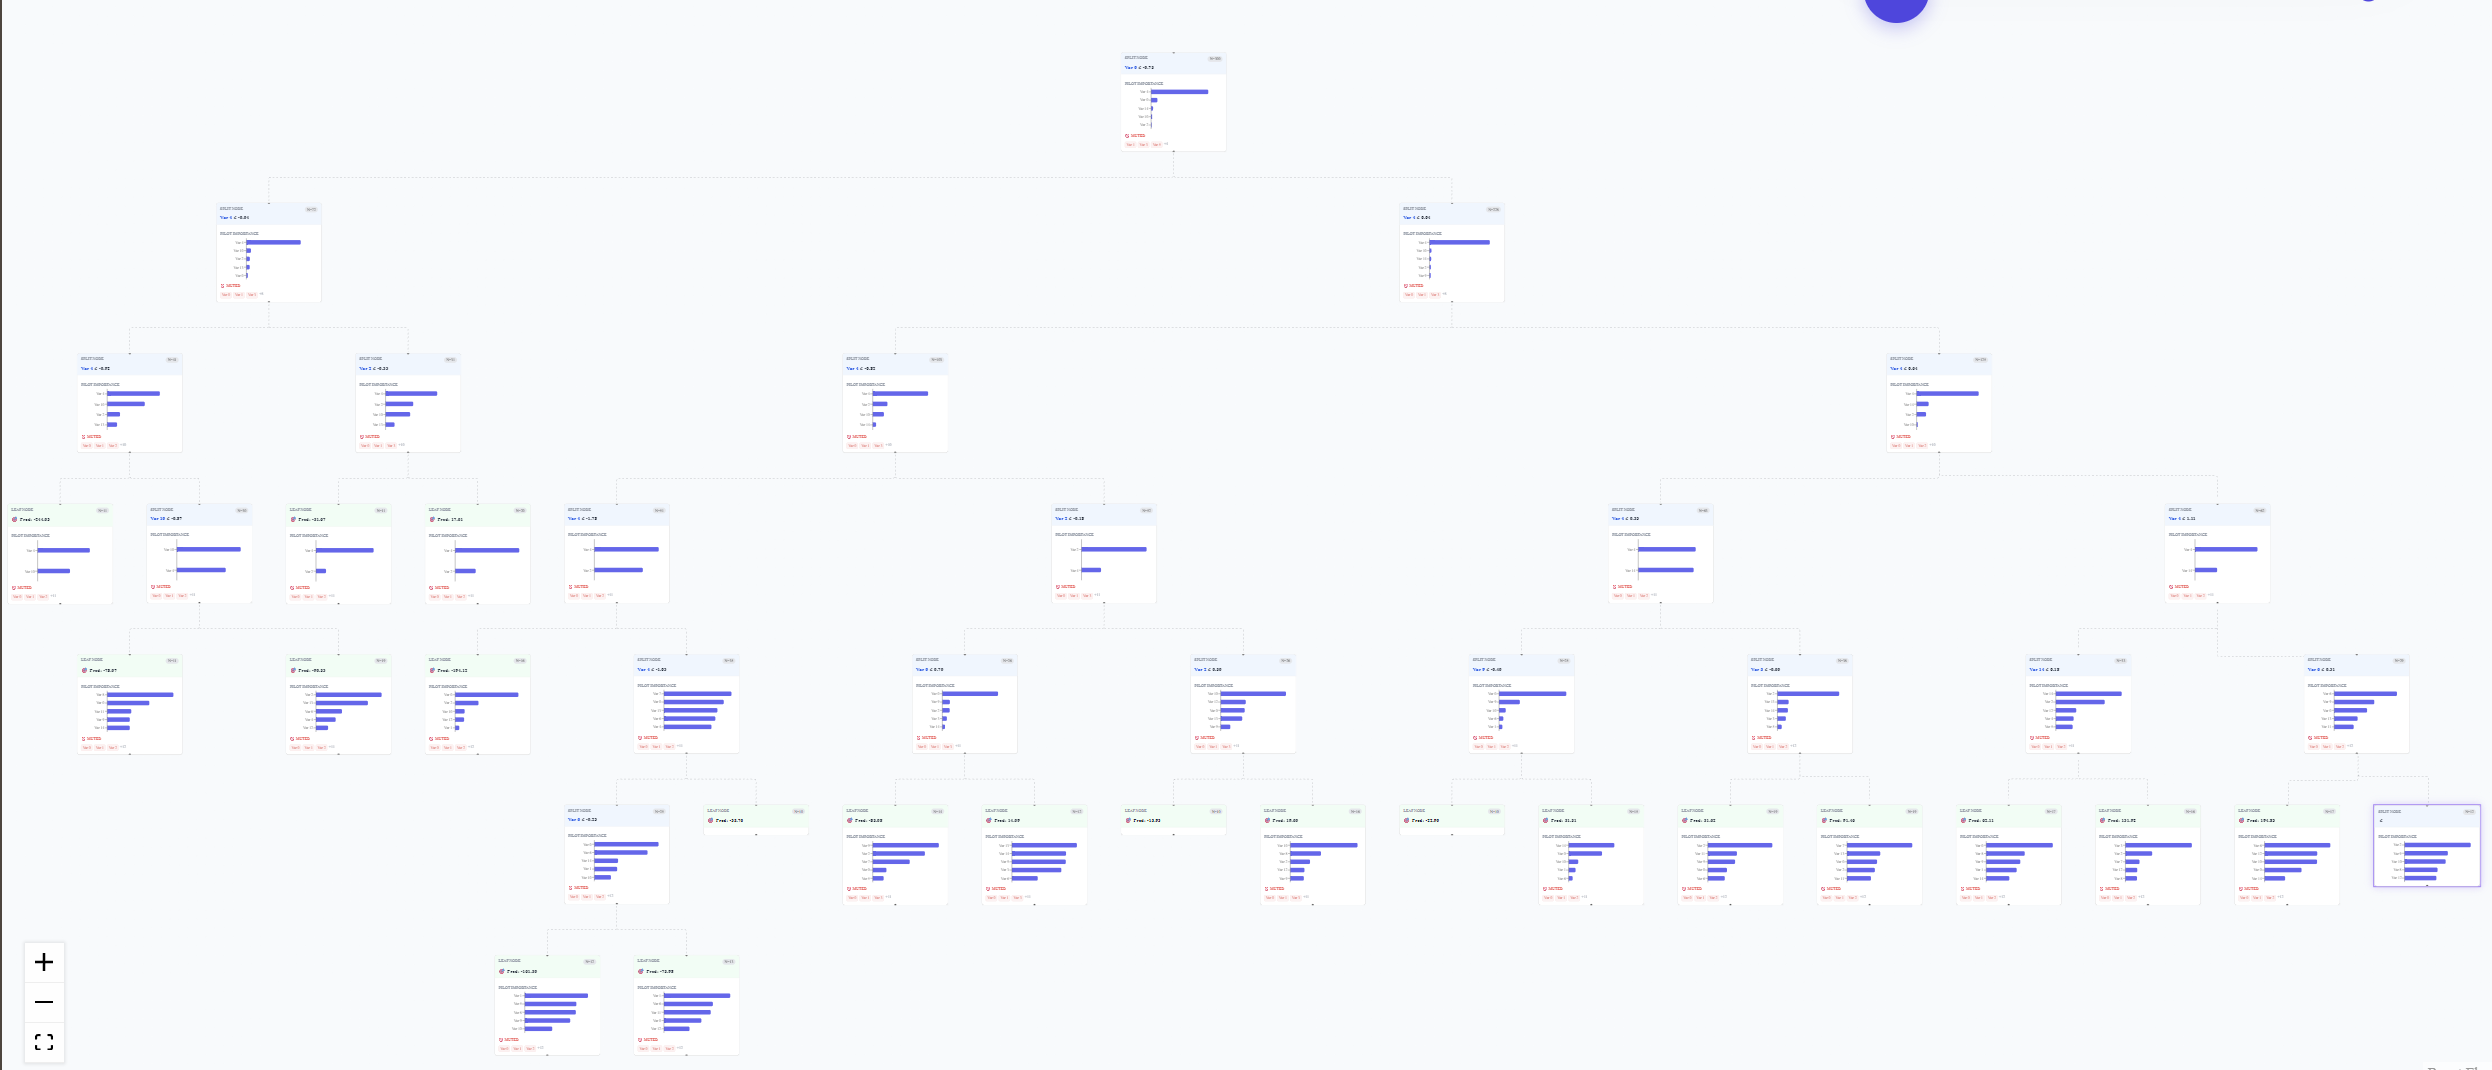

                Leaf Node ( Green ) ------------------------------------------------------------------------------------------Inter Node ( Blue ) 

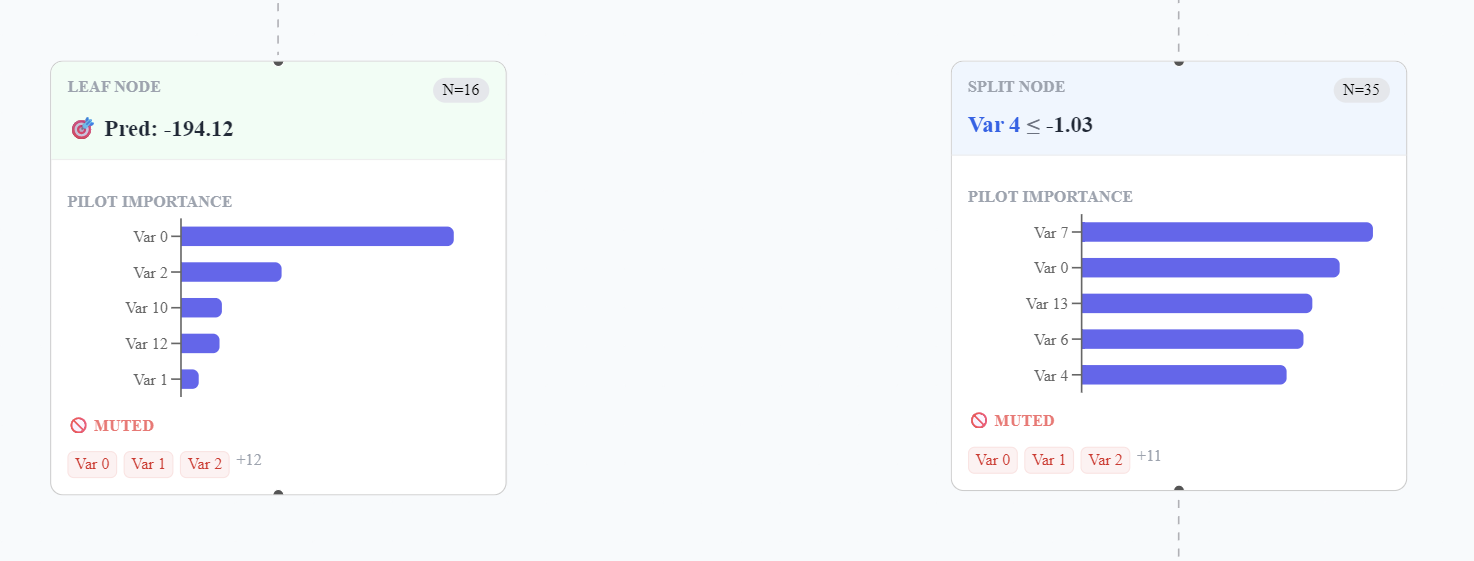

# Tree Structure

#### Imports

In [54]:
!pip install jupyter -upgrade 
!pip install numpy pandas scikit-learn joblib tqdm
!pip install xgboost
!pip install matplotlib
!pip install seaborn

# =========================
# Standard library
# =========================
import warnings
import contextlib
import time
from dataclasses import dataclass, field
from typing import List, Set, Optional, Dict

# =========================
# Third-party
# =========================
import numpy as np
import pandas as pd
import joblib
from joblib import Parallel, delayed
from tqdm.auto import tqdm

# =========================
# Scikit-learn base utils
# =========================
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.utils import check_X_y, check_array
from sklearn.utils.validation import check_is_fitted
from sklearn.exceptions import ConvergenceWarning
from sklearn.utils.parallel import Parallel, delayed


# =========================
# Preprocessing & pipeline
# =========================
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

# =========================
# Models
# =========================
from sklearn.ensemble import (
    RandomForestRegressor, RandomForestClassifier,
    ExtraTreesRegressor, ExtraTreesClassifier
)
from sklearn.ensemble import GradientBoostingClassifier

from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.linear_model import Lasso, Ridge, LogisticRegression
from sklearn.neural_network import MLPRegressor, MLPClassifier

# =========================
# Model selection
# =========================
from sklearn.model_selection import (
    RandomizedSearchCV,
    cross_val_predict
)

# =========================
# Metrics
# =========================
from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_error,
    median_absolute_error,
    max_error,
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    matthews_corrcoef,
    balanced_accuracy_score
)
from xgboost import XGBClassifier

# =========================
# Datasets
# =========================
from sklearn.datasets import make_regression
from sklearn.model_selection import ShuffleSplit

import warnings
from sklearn.exceptions import ConvergenceWarning

# Ignore convergence warnings from MLP
warnings.filterwarnings("ignore", category=ConvergenceWarning)

import pandas as pd
import numpy as np
import time
import warnings
from tqdm import tqdm
from sklearn.model_selection import RandomizedSearchCV, cross_val_predict
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, median_absolute_error, max_error

# --- Model Imports ---
from sklearn.linear_model import Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, GradientBoostingRegressor
from sklearn.neural_network import MLPRegressor
from xgboost import XGBRegressor
warnings.filterwarnings('ignore')

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

import pandas as pd
import matplotlib.pyplot as plt
import textwrap
import pandas as pd
import numpy as np
import time
import warnings
from tqdm import tqdm
from sklearn.model_selection import RandomizedSearchCV, cross_val_predict
from sklearn.metrics import (
    accuracy_score, 
    f1_score, 
    precision_score, 
    recall_score, 
    balanced_accuracy_score, 
    matthews_corrcoef # <--- Added per your function
)

# --- Model Imports ---
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier



Usage:   
  pip install [options] <requirement specifier> [package-index-options] ...
  pip install [options] -r <requirements file> [package-index-options] ...
  pip install [options] [-e] <vcs project url> ...
  pip install [options] [-e] <local project path> ...
  pip install [options] <archive url/path> ...

no such option: -u


In [24]:
# --- Context Manager for Progress Bar ---
@contextlib.contextmanager
def tqdm_joblib(tqdm_object):
    class TqdmBatchCompletionCallback(joblib.parallel.BatchCompletionCallBack):
        def __call__(self, *args, **kwargs):
            tqdm_object.update(n=self.batch_size)
            return super().__call__(*args, **kwargs)
    old_batch_callback = joblib.parallel.BatchCompletionCallBack
    joblib.parallel.BatchCompletionCallBack = TqdmBatchCompletionCallback
    try:
        yield tqdm_object
    finally:
        joblib.parallel.BatchCompletionCallBack = old_batch_callback
        tqdm_object.close()

### Class : Node

In [4]:
@dataclass
class RLTNode:
    node_id: int
    is_leaf: bool = False
    
    # Splitting info
    feature_indices: List[int] = field(default_factory=list) 
    split_weights: List[float] = field(default_factory=list)
    threshold: float = None
    
    # Tree structure
    left: 'RLTNode' = None
    right: 'RLTNode' = None
    
    # Leaf content
    prediction: float = None
    model: object = None      # Stores the Ridge/Logistic Regression object
    
    # Metadata
    muted_vars: Set[int] = field(default_factory=set)
    sample_indices: np.ndarray = None

### Class : RLTBuilder

The RLTBuilder is the worker engine responsible for constructing exactly one single tree within the RLT ensemble. It does not manage the forest; it receives a specific bootstrap sample of data and recursively partitions it until stopping criteria are met. <br>
Key Responsibilities:
- Recursive Growth: It runs the main tree-building loop (_fit_recursive), moving from the root down to the leaves.
- Reinforcement (The "Pilot" Model): At every internal node, it trains a temporary, internal Random Forest to calculate variable importance and mute (remove) weak variables from future splits in that branch.
- Advanced Splitting: It calculates the optimal cut points, handling both standard axis-parallel splits and Linear Combinations (oblique splits) if configured.
- Leaf Embedding ("Deep Forest"): Upon reaching a terminal node, instead of just storing a mean value, it can train and store a complex Nested Model (e.g., a mini Random Forest, Ridge Regression, or Logistic Regression) on the leaf's local data.

In [5]:
from sklearn.linear_model import Ridge, LogisticRegression
import numpy as np
import warnings
from sklearn.exceptions import ConvergenceWarning

class RLTBuilder:
    def __init__(self, model_type, nmin, mtry, alpha,
                 nsplit, split_gen,
                 reinforcement, muting_rate, protect_n,
                 combsplit, combsplit_th,
                 embed_config,       
                 # leaf_embed_config removed
                 track_obs, 
                 # leaf_model removed (fixed to Ridge/Linear)
                 pilot_model):
        
        self.model_type = model_type
        self.nmin = nmin
        self.mtry = mtry
        self.alpha = alpha
        self.nsplit = nsplit
        self.split_gen = split_gen
        
        self.reinforcement = reinforcement
        self.muting_rate = muting_rate
        self.protect_n = protect_n
        self.embed_config = embed_config
        # self.leaf_embed_config removed
        
        self.combsplit = combsplit
        self.combsplit_th = combsplit_th
        self.track_obs = track_obs
        # self.leaf_model removed
        self.pilot_model = pilot_model
        
        self.node_count = 0

    def fit(self, X, y, sample_indices_in_bag):
        return self._fit_recursive(X, y, sample_indices_in_bag, muted_set=set(), depth=0)

    def _fit_recursive(self, X, y, current_indices, muted_set, depth):
        X_curr = X[current_indices]
        y_curr = y[current_indices]
        n_samples = len(current_indices)

        is_pure = (len(np.unique(y_curr)) == 1) if self.model_type == "classification" else (np.var(y_curr) < 1e-8)
        
        if n_samples < self.nmin or is_pure or depth > 20:
            return self._make_leaf(X_curr, y_curr, current_indices, muted_set)

        # --- REINFORCEMENT (Pilot Model) ---
        run_reinforcement = self.reinforcement and (n_samples > self.embed_config['n_th'])
        
        if run_reinforcement:
            allowed = [i for i in range(X.shape[1]) if i not in muted_set]
            if len(allowed) < 2: allowed = list(range(X.shape[1]))
            
            X_embed = X_curr[:, allowed]
            
            # =========================================================
            # DYNAMIC PILOT SELECTION
            # =========================================================
            ntrees = self.embed_config['ntrees']
            embed_est = None
            raw_imps = None
            
            # 1. Random Forest Pilot
            if self.pilot_model == "random_forest":
                if self.model_type == "regression":
                    embed_est = RandomForestRegressor(n_estimators=ntrees, max_depth=3, max_features='sqrt', n_jobs=1)
                else:
                    embed_est = RandomForestClassifier(n_estimators=ntrees, max_depth=3, max_features='sqrt', n_jobs=1)
                embed_est.fit(X_embed, y_curr)
                raw_imps = embed_est.feature_importances_

            # 2. Extra Trees Pilot
            elif self.pilot_model == "extra_trees":
                if self.model_type == "regression":
                    embed_est = ExtraTreesRegressor(n_estimators=ntrees, max_depth=3, max_features='sqrt', n_jobs=1)
                else:
                    embed_est = ExtraTreesClassifier(n_estimators=ntrees, max_depth=3, max_features='sqrt', n_jobs=1)
                embed_est.fit(X_embed, y_curr)
                raw_imps = embed_est.feature_importances_

            # 3. Decision Tree Pilot
            elif self.pilot_model == "decision_tree":
                if self.model_type == "regression":
                    embed_est = DecisionTreeRegressor(max_depth=5)
                else:
                    embed_est = DecisionTreeClassifier(max_depth=5)
                embed_est.fit(X_embed, y_curr)
                raw_imps = embed_est.feature_importances_

            # 4. Linear / Lasso Pilot
            elif self.pilot_model == "linear":
                scaler = StandardScaler()
                X_sc = scaler.fit_transform(X_embed)
                if self.model_type == "regression":
                    embed_est = Lasso(alpha=0.1, max_iter=500)
                    embed_est.fit(X_sc, y_curr)
                    raw_imps = np.abs(embed_est.coef_)
                else:
                    embed_est = LogisticRegression(penalty='l1', solver='liblinear', C=0.5, max_iter=200)
                    embed_est.fit(X_sc, y_curr)
                    if embed_est.coef_.ndim > 1:
                        raw_imps = np.sum(np.abs(embed_est.coef_), axis=0)
                    else:
                        raw_imps = np.abs(embed_est.coef_).flatten()

            # 5. ANN Pilot
            elif self.pilot_model == "ann":
                hidden_layer_sizes = (10,) 
                max_iter = 500
                scaler = StandardScaler()
                X_sc = scaler.fit_transform(X_embed)

                if self.model_type == "regression":
                    embed_est = MLPRegressor(hidden_layer_sizes=hidden_layer_sizes, 
                                             solver='lbfgs', 
                                             max_iter=max_iter, 
                                             activation='relu',
                                             random_state=None)
                else:
                    embed_est = MLPClassifier(hidden_layer_sizes=hidden_layer_sizes, 
                                              solver='lbfgs', 
                                              max_iter=max_iter, 
                                              activation='relu',
                                              random_state=None)
                
                with warnings.catch_warnings():
                    warnings.filterwarnings("ignore", category=ConvergenceWarning)
                    try:
                        embed_est.fit(X_sc, y_curr)
                        first_layer_weights = np.abs(embed_est.coefs_[0])
                        raw_imps = np.sum(first_layer_weights, axis=1)
                    except Exception:
                        raw_imps = np.zeros(X_embed.shape[1])

            # Default fallback
            else:
                if self.model_type == "regression":
                    embed_est = RandomForestRegressor(n_estimators=ntrees, max_depth=3, n_jobs=1)
                else:
                    embed_est = RandomForestClassifier(n_estimators=ntrees, max_depth=3, n_jobs=1)
                embed_est.fit(X_embed, y_curr)
                raw_imps = embed_est.feature_importances_

            # =========================================================
            # MUTING LOGIC
            # =========================================================
            if raw_imps is None or np.sum(raw_imps) == 0:
                child_muted_set = muted_set
                candidate_pool = allowed
            else:
                VI = {allowed[i]: imp for i, imp in enumerate(raw_imps)}
                sorted_vars = sorted(VI.keys(), key=lambda k: VI[k], reverse=True)
                
                n_mute = min(max(0, len(allowed) - self.protect_n), int(len(allowed) * self.muting_rate))
                child_muted_set = muted_set.union(set(sorted_vars[-n_mute:]) if n_mute > 0 else set())
                candidate_pool = sorted_vars
                
        else:
            child_muted_set = muted_set
            candidate_pool = [i for i in range(X.shape[1]) if i not in muted_set]
            if not candidate_pool: candidate_pool = list(range(X.shape[1]))

        # --- SPLITTING ---
        n_try = min(self.mtry, len(candidate_pool))
        split_candidates = candidate_pool[:n_try] if run_reinforcement else np.random.choice(candidate_pool, n_try, replace=False)
        
        best_split = self._find_best_split(X_curr, y_curr, split_candidates)

        if best_split is None:
            return self._make_leaf(X_curr, y_curr, current_indices, muted_set)

        feat_idxs, weights, thr, left_mask, _ = best_split
        
        node = RLTNode(node_id=self.node_count)
        self.node_count += 1
        node.feature_indices = feat_idxs
        node.split_weights = weights
        node.threshold = thr
        node.muted_vars = muted_set
        
        node.left = self._fit_recursive(X, y, current_indices[left_mask], child_muted_set, depth+1)
        node.right = self._fit_recursive(X, y, current_indices[~left_mask], child_muted_set, depth+1)
        return node
    
    def _find_best_split(self, X, y, candidates):
        best_gain = -np.inf
        best_cfg = None
        iterations = max(self.nsplit, 10) if (self.combsplit > 1 and len(candidates) >= self.combsplit) else 1
        for _ in range(iterations):
            if self.combsplit > 1 and len(candidates) >= self.combsplit:
                c_vars = np.random.choice(candidates, self.combsplit, replace=False)
                c_weights = np.random.choice([-1, 1], size=self.combsplit)
                vals = np.dot(X[:, c_vars], c_weights)
                res = self._optimize_threshold(vals, y)
                if res and res[2] > best_gain:
                    best_gain = res[2]
                    best_cfg = (c_vars.tolist(), c_weights.tolist(), res[0], res[1], res[2])
            else:
                for f in candidates:
                    vals = X[:, f]
                    res = self._optimize_threshold(vals, y)
                    if res and res[2] > best_gain:
                        best_gain = res[2]
                        best_cfg = ([f], [1.0], res[0], res[1], res[2])
        return best_cfg

    def _optimize_threshold(self, values, y):
        unique_vals = np.unique(values)
        if len(unique_vals) < 2: return None
        thresholds = unique_vals
        if self.nsplit > 0 and self.split_gen == "random":
             thresholds = np.random.choice(unique_vals, size=min(self.nsplit, len(unique_vals)), replace=False)
        best = -np.inf
        best_t, best_m = None, None
        n = len(y)
        for t in thresholds:
            l_mask = values <= t
            n_l = np.sum(l_mask)
            if n_l < self.alpha * n or (n-n_l) < self.alpha * n: continue
            if n_l < self.nmin or (n-n_l) < self.nmin: continue
            if self.model_type == "regression":
                gain = np.var(y)*n - (np.var(y[l_mask])*n_l + np.var(y[~l_mask])*(n-n_l))
            else:
                def g(z): return 1.0 - np.sum((np.unique(z, return_counts=True)[1]/len(z))**2)
                gain = g(y) - ((n_l/n)*g(y[l_mask]) + ((n-n_l)/n)*g(y[~l_mask]))
            if gain > best: best, best_t, best_m = gain, t, l_mask
        return (best_t, best_m, best) if best_t is not None else None

    # ==========================================================================
    #  FIXED LEAF MODEL: RIDGE REGRESSION / LOGISTIC (Piecewise Linear)
    # ==========================================================================
    def _make_leaf(self, X_leaf, y_leaf, current_indices, muted_set):
        node = RLTNode(node_id=self.node_count, is_leaf=True)
        self.node_count += 1
        node.n_samples = len(y_leaf)
        node.muted_vars = muted_set
        if self.track_obs: node.sample_indices = current_indices

        # 1. Base Prediction (Fallback: Mean / Mode)
        if self.model_type == "regression":
            node.prediction = np.mean(y_leaf)
        else:
            vals, counts = np.unique(y_leaf, return_counts=True)
            node.prediction = vals[np.argmax(counts)]

        # 2. Safety Checks
        # Need enough samples to fit a regression line safely
        if len(y_leaf) < 5 or len(np.unique(y_leaf)) < 2:
            return node

        # 3. Fit Linear Model
        try:
            if self.model_type == "regression":
                # Check for variance in y to avoid fitting noise
                if np.std(y_leaf) > 1e-9:
                    # RIDGE REGRESSION (Piecewise Linear)
                    # alpha=1.0 is standard regularization
                    model = Ridge(alpha=1.0)
                    model.fit(X_leaf, y_leaf)
                    node.model = model
            else:
                # LOGISTIC REGRESSION (Piecewise Linear Boundary)
                if len(np.unique(y_leaf)) > 1:
                    model = LogisticRegression(max_iter=100, solver='liblinear')
                    model.fit(X_leaf, y_leaf)
                    node.model = model
        except Exception:
            # If matrix is singular or fails, we fallback to the Mean/Mode calculated above
            node.model = None

        return node

### Class : RLT

This is the main RLT Class that the user interacts 

It combines:
- The Data Structures (RLTNode).
- The Worker Engine (RLTBuilder) which handles the recursion, reinforcement, linear splits, and leaf embedding.
- The Main Estimator (RLT) using the specific corrected logic you provided (fixed muting rate, parameter handling, and parallelization).

In [6]:
class RLT(BaseEstimator): 
    def __init__(self, 
                 ntrees=100, 
                 model="regression",
                 
                 # --- PILOT CONFIG ---
                 # Options: "random_forest", "extra_trees", "decision_tree", "linear", "ann"
                 pilot_model="random_forest", 
                 
                 # leaf_model REMOVED (Fixed to Ridge/Linear in Builder)
                 
                 mtry=None, 
                 nmin=None, 
                 alpha=0.1, 
                 split_gen="random", 
                 nsplit=1,
                 resample_prob=0.9, 
                 replacement=True,
                 reinforcement=True,
                 muting=-1,
                 protect=None,
                 combsplit=1,
                 combsplit_th=0.25,
                 track_obs=False,
                 importance=True,
                 
                 # Pilot Config Params (Keep these for the reinforcement step)
                 embed_ntrees=50,
                 embed_mtry=0.5,
                 embed_nmin=None,
                 embed_n_th=None,
                 
                 # Leaf Config Params REMOVED (No longer needed)
                 
                 n_jobs=-1):
        
        self.ntrees = ntrees
        self.model = model
        self.pilot_model = pilot_model
        
        self.mtry = mtry
        self.nmin = nmin
        self.alpha = alpha
        self.split_gen = split_gen
        self.nsplit = nsplit
        self.resample_prob = resample_prob
        self.replacement = replacement
        
        self.reinforcement = reinforcement
        self.muting = muting
        self.protect = protect
        self.combsplit = combsplit
        self.combsplit_th = combsplit_th
        self.track_obs = track_obs
        self.importance = importance
        
        self.embed_ntrees = embed_ntrees
        self.embed_mtry = embed_mtry
        self.embed_nmin = embed_nmin
        self.embed_n_th = embed_n_th
        
        self.n_jobs = n_jobs
        self.trees_ = []

    def fit(self, X, y):
        X, y = check_X_y(X, y)
        n_samples, n_features = X.shape
        
        # Defaults
        if self.mtry is None: self.mtry = max(1, int(n_features / 3))
        if self.nmin is None: self.nmin = max(1, int(np.log(n_samples)))
        if self.protect is None: self.protect = int(np.log(n_features))
        if self.embed_nmin is None: self.embed_nmin = int(n_samples**(1/3))
        if self.embed_n_th is None: self.embed_n_th = 4 * self.nmin
        
        # Muting Rate Calculation
        if self.muting == -1:
            if self.reinforcement:
                base_term = np.log(n_features) / n_features if n_features > 1 else 0
                offset = 0.35 
                if n_features <= 50: offset = 0.50
                if n_samples < 100: offset -= 0.10
                real_muting = max(0.0, min(0.9, base_term + offset))
            else:
                real_muting = 0.0
        else:
            real_muting = self.muting

        # Config dictionary for the Pilot model
        embed_config = {
            'ntrees': self.embed_ntrees,
            'mtry': max(1, int(self.embed_mtry * n_features)) if isinstance(self.embed_mtry, float) else self.embed_mtry,
            'nmin': self.embed_nmin,
            'n_th': self.embed_n_th
        }
        
        # Seed generation
        seeds = np.random.randint(0, 1e9, self.ntrees)
        
        # Parallel Fit
        self.trees_ = Parallel(n_jobs=self.n_jobs)(
            delayed(self._fit_single_tree)(X, y, seed, real_muting, embed_config) 
            for seed in seeds
        )
        return self

    def _fit_single_tree(self, X, y, seed, muting_rate, embed_config):
        np.random.seed(seed)
        n_samples = X.shape[0]
        sample_size = int(n_samples * self.resample_prob)
        indices = np.random.choice(n_samples, sample_size, replace=self.replacement)
        
        builder = RLTBuilder(
            model_type=self.model,
            nmin=self.nmin,
            mtry=self.mtry,
            alpha=self.alpha,
            nsplit=self.nsplit,
            split_gen=self.split_gen,
            reinforcement=self.reinforcement,
            muting_rate=muting_rate,
            protect_n=self.protect,
            combsplit=self.combsplit,
            combsplit_th=self.combsplit_th,
            embed_config=embed_config,
            # leaf_embed_config REMOVED from Builder call
            track_obs=self.track_obs,
            # leaf_model REMOVED from Builder call
            pilot_model=self.pilot_model
        )
        
        return builder.fit(X, y, indices)
    
    def predict(self, X):
        X = check_array(X)
        preds = Parallel(n_jobs=self.n_jobs)(
            delayed(self._predict_tree)(tree, X) for tree in self.trees_
        )
        preds = np.array(preds)
        
        if self.model == "regression":
            return np.mean(preds, axis=0)
        else:
            from scipy.stats import mode
            res, _ = mode(preds, axis=0, keepdims=False)
            return res
        
    def score(self, X, y, sample_weight=None):
        y_pred = self.predict(X)
        if self.model == "regression":
            return r2_score(y, y_pred, sample_weight=sample_weight)
        else:
            return accuracy_score(y, y_pred, sample_weight=sample_weight)

    def _predict_tree(self, node, X):
        return np.array([self._predict_row(node, row) for row in X])

    def _predict_row(self, node, row):
        if node.is_leaf:
            if node.model is not None:
                return node.model.predict(row.reshape(1, -1))[0]
            return node.prediction
        
        val = 0.0
        if len(node.feature_indices) == 1 and len(node.split_weights) == 1:
            val = row[node.feature_indices[0]]
        else:
            for i, idx in enumerate(node.feature_indices):
                val += row[idx] * node.split_weights[i]
                
        if val <= node.threshold:
            return self._predict_row(node.left, row)
        else:
            return self._predict_row(node.right, row)

 # Research

To systematically evaluate the behavior and performance of the considered models, we conduct experiments on **four complementary synthetic scenarios**. Using synthetic datasets allows full control over the data-generating mechanisms, making it possible to clearly assess each model’s ability to capture linearity, non-linearity, interactions, correlations, and sparsity.

The scenarios are defined as follows:

- **Scenario 1 – Classification with independent covariates and non-linear relationship**  
  A binary classification setting where covariates are independent and uniformly distributed. The decision boundary is non-linear, designed to challenge linear classifiers and highlight the benefits of flexible models.

- **Scenario 2 – Non-linear regression model with independent covariates and threshold effect**  
  A regression scenario with independent covariates and a non-linear response function involving interaction and threshold effects. This setup evaluates a model’s capacity to capture localized non-linear behavior.

- **Scenario 3 – Checkerboard model with strongly correlated covariates**  
  A highly non-linear regression model with a checkerboard-like structure and strong correlations between variables. This scenario is particularly demanding and is used to test robustness to feature dependence and complex interaction patterns.

- **Scenario 4 – Linear model (Lasso benchmark)**  
  A purely linear regression model with sparse coefficients, serving as a benchmark for Lasso and other linear regularized methods. In this setting, complex non-linear models are not expected to outperform linear approaches.

These four scenarios together provide a comprehensive and controlled framework to compare models across increasing levels of complexity, from linear to strongly non-linear and correlated settings.


## Synthetic datasets generation

### Classification

**Scenario 1 :** Classification avec covariables indépendantes et relation non-linéaire

In [100]:
"""
Classification with Uniform[0,1] features and non-linear relationship.

Steps:
    1. X ~ Uniform[0,1]^p
    2. Non-linear checkerboard decision rule using X1, X2
    3. Binary labels {0,1}
    4. Optional label noise (flip_y)
"""

def generate_nonlinear_uniform_classification(
    n_samples=1000,
    p=5,
    seed=42,
    n_blocks=4,
    flip_y=0.05
):
    rng = np.random.default_rng(seed)

    # --- 1) Uniform features ---
    X = rng.uniform(0, 1, size=(n_samples, p))

    # --- 2) Non-linear checkerboard rule ---
    X1 = X[:, 0]
    X2 = X[:, 1]

    block_x = (X1 * n_blocks).astype(int)
    block_y = (X2 * n_blocks).astype(int)

    # XOR / checkerboard pattern
    y = (block_x + block_y) % 2   # {0,1}

    # --- 3) Label noise ---
    if flip_y > 0:
        flips = rng.random(n_samples) < flip_y
        y[flips] = 1 - y[flips]

    return X, y


# Example usage
sc1_X, sc1_y = generate_nonlinear_uniform_classification(
    n_samples=2000,
    p=8,
    n_blocks=6,
    flip_y=0.1
)

print(sc1_X.shape, sc1_y.shape)
print("Class balance:", np.bincount(sc1_y))

(2000, 8) (2000,)
Class balance: [1009  991]


In [102]:
np.unique(sc1_y)

array([0, 1])

### Regression

**Scenario 2 :** Modèle non-linéaire avec covariables indépendantes et effet de seuil

In [8]:
"""
    Scenario 2: Non-linear model with independent covariates
        X ~ Uniform[0, 1]^p
        Y = 100*(X1 - 0.5)^2 * (X2 - 0.25)_+ + ε
        ε ~ N(0, 1)
"""

def generate_scenario2(n_samples=1000, p=5, seed=42):
    
    rng = np.random.default_rng(seed)

    # Generate covariates
    X = rng.uniform(0, 1, size=(n_samples, p))

    # Extract X1 and X2 (python index: 0 and 1)
    X1 = X[:, 0]
    X2 = X[:, 1]

    # Positive part (x)_+ = max(x, 0)
    positive_part = np.maximum(X2 - 0.25, 0)

    # Noise
    eps = rng.normal(0, 1, size=n_samples)

    # Response
    Y = 100 * (X1 - 0.5)**2 * positive_part + eps

    return X, Y

# Example usage:
sc2_X, sc2_y = generate_scenario2(n_samples=2000, p=10)
print(sc2_X.shape, sc2_y.shape)

(2000, 10) (2000,)


**Scenario 3 :** Modèle de type "checkerboard" avec fortes corrélations entre variables

In [9]:
from scipy.stats import norm

"""
    Regression with strong feature correlations + checkerboard-like interactions.

    Steps:
    1. Generate strongly correlated Gaussian variables.
    2. Convert to Uniform[0,1] via Φ (Gaussian CDF).
    3. Checkerboard response:
            Y = +1 on some blocks, -1 on others, alternating.
        (like a 2D XOR generalization)
    4. Add noise N(0,1).
"""

def generate_checkerboard_regression(
    n_samples=1000, p=5, rho=0.8, seed=42, n_blocks=4
):
    

    rng = np.random.default_rng(seed)

    # --- 1) Correlated Gaussian variables ---
    # Build correlation matrix
    Sigma = rho * np.ones((p, p)) + (1 - rho) * np.eye(p)
    L = np.linalg.cholesky(Sigma)

    Z = rng.normal(size=(n_samples, p))
    X_gaussian = Z @ L.T

    # --- 2) Convert to Uniform[0,1] ---
    X = norm.cdf(X_gaussian)   # Uniform with strong dependence

    # --- 3) Checkerboard interaction using X1 and X2 only ---
    X1 = X[:, 0]
    X2 = X[:, 1]

    # Determine which block each point falls in
    block_x = (X1 * n_blocks).astype(int)
    block_y = (X2 * n_blocks).astype(int)

    # Checkerboard parity (block_x + block_y) mod 2
    pattern = ((block_x + block_y) % 2)

    # Map to +1 / -1 alternating tiles
    signal = 2 * pattern - 1  # 0→-1, 1→+1

    # --- 4) Response with nonlinearity + noise ---
    noise = rng.normal(0, 1, size=n_samples)
    Y = signal + 0.1 * noise

    return X, Y


# Example usage:
sc3_X, sc3_y = generate_checkerboard_regression(n_samples=2000, p=8, rho=0.9)
print(sc3_X.shape, sc3_y.shape)


(2000, 8) (2000,)


**Scenario 4 :** Modèle linéaire (benchmark pour Lasso)

In [10]:

"""
Scenario 4: Linear regression (Lasso benchmark)
    X ~ Uniform[0,1]^p
    Y = sum_{j=1}^{n_inf} beta_j * X_j + ε
    ε ~ N(0,1)
"""
def generate_scenario4_lasso(
    n_samples=1000,
    p=10,
    n_informative=3,
    seed=42
):

    rng = np.random.default_rng(seed)

    # --- 1) Covariates ---
    X = rng.uniform(0, 1, size=(n_samples, p))

    # --- 2) Sparse linear coefficients ---
    beta = np.zeros(p)
    beta[:n_informative] = rng.uniform(2, 5, size=n_informative)

    # --- 3) Noise ---
    eps = rng.normal(0, 1, size=n_samples)

    # --- 4) Response ---
    Y = X @ beta + eps

    return X, Y, beta


# Example usage
sc4_X, sc4_y, beta_true = generate_scenario4_lasso(
    n_samples=2000,
    p=10,
    n_informative=3
)

print(sc4_X.shape, sc4_y.shape)
print("True beta:", beta_true)


(2000, 10) (2000,)
True beta: [4.22231826 4.9874194  2.12293193 0.         0.         0.
 0.         0.         0.         0.        ]


## Tuning : Finding the best RLT hyperparameters

For a Reinforcement Learning Tree (RLT) with this specific signature, the parameters fall into three categories: 
- structural (standard random forest params), 
- reinforcement (the "learning" part of the split selection) 
- leaf modeling (what happens at the terminal nodes).
To get the best performance without an explosion in training time, you should fix the computational parameters and tune the ones that control the bias-variance trade-off and the strength of the reinforcement signal.<br><br>
**The Strategy :**
- Fix: ntrees (set it high enough to stabilize), n_jobs, and sampling parameters like replacement.
- Tune (Primary): mtry, nmin, and leaf_model.These have the highest impact on model architecture.
- Tune (Secondary - RLT specific): nsplit, reinforcement, and combsplit.These control how "aggressive" the reinforcement learning aspect is.

 ### <b>Personalise RLT search grid params </b> 

In [11]:
param_distributions = {
    # --- Structural Tree Params (Speed Optimization) ---
    # Larger leaves (50) are much faster and stabilize 'Ridge' leaf models.
    # Smaller leaves (20) capture finer details but slow things down.
    'nmin': [20, 50],         

    # 'random' is significantly faster than 'best' (which requires sorting).
    # RLT relies on randomness + reinforcement, so 'best' is often redundant.
    'split_gen': ['random'],      

    # Keep nsplit low (1) when using 'random'. Checking 3+ points per feature 
    # slows training linearly with minimal gain for RLT.
    'nsplit': [1],          

    # Standard subsampling. 0.8 is slightly faster than 0.9.
    'resample_prob': [0.7,0.9],  

    # Try standard feature counts. 
    # (Adjust '10' based on your actual feature count; sqrt(p) is standard).
    'mtry': [5, 10],          
    
    # 0.0 is standard accuracy. 0.05 provides a slight speedup by pruning early.
    'alpha': [0.0, 0.05],          

    # --- RLT Reinforcement Params (The Secret Sauce) ---
    'reinforcement': [True], 
    
    
    'pilot_model': ['random_forest', 'extra_trees', 'decision_tree', 'linear', 'ann'],
    
    # --- Muting Optimization ---
    # -1 (Auto) calculates based on dataset size (smartest).
    # 0.3 (Fixed 30%) is a good "aggressive" setting to test against Auto.
    'muting': [-1, 0.3], 
    
    # Logarithmic protection is usually best. 
    # If you have 20 features, keep 2-3 protected.
    'protect': [2, 3],
    
    # --- Complex Splitting ---
    # KEEP AT 1 for speed. 
    # Combsplit > 1 calculates linear combinations (PCA-like) at every node. 
    # It is very slow and only helps in specific "checkerboard" data structures.
    'combsplit': [1,2] 
}
# Total nuber of combinations is 17,280 x 3 folds =  51,840 combination 
# we will sacrifice the C.V folds for the sake of exploration 
# we will limit it by n_iter=50 for randomized search 
# Define a "1-Fold" strategy (Train on 80%, Test on 20%, ONCE)
single_split_cv = ShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
cv_folds = 2
n_iter_search = 200

### Gridsearch for tuning ( unused )

for regression models

In [12]:
'''from sklearn.model_selection import GridSearchCV
from sklearn.datasets import make_regression

# 1. Data
X_reg, y_reg = make_regression(n_samples=200, n_features=10, random_state=42)

# 2. Setup Model (model="regression")
rlt_reg = RLT(model="regression", n_jobs=1)

# 3. Grid Search
random_search_grid = {
    'leaf_model': ['mean', 'decision_trees', 'extra_trees', "rando_forest" ], # maybe skip RF for speed
    'muting': [0, 1, 2],
    'protect': [None, 2, 5],
    'resample_prob': [0.8],  ## mathematically the best 
    'split_gen': ['random', 'best'],
    # 5. Mtry: 'sqrt' is often too small for regression. 
    # 0.5 (half features) to 0.8 usually works best for regression problems.
    'mtry': [3,5, 8],
    'nmin': [10, 20],
    'nsplit': [1, 5]
}

gs_reg = GridSearchCV(rlt_reg, param_grid_reg, cv=3, verbose=1)
gs_reg.fit(X_reg, y_reg)

print("Best Regression R2:", gs_reg.best_score_)
print("Best Params:", gs_reg.best_params_)'''

'from sklearn.model_selection import GridSearchCV\nfrom sklearn.datasets import make_regression\n\n# 1. Data\nX_reg, y_reg = make_regression(n_samples=200, n_features=10, random_state=42)\n\n# 2. Setup Model (model="regression")\nrlt_reg = RLT(model="regression", n_jobs=1)\n\n# 3. Grid Search\nrandom_search_grid = {\n    \'leaf_model\': [\'mean\', \'decision_trees\', \'extra_trees\', "rando_forest" ], # maybe skip RF for speed\n    \'muting\': [0, 1, 2],\n    \'protect\': [None, 2, 5],\n    \'resample_prob\': [0.8],  ## mathematically the best \n    \'split_gen\': [\'random\', \'best\'],\n    # 5. Mtry: \'sqrt\' is often too small for regression. \n    # 0.5 (half features) to 0.8 usually works best for regression problems.\n    \'mtry\': [3,5, 8],\n    \'nmin\': [10, 20],\n    \'nsplit\': [1, 5]\n}\n\ngs_reg = GridSearchCV(rlt_reg, param_grid_reg, cv=3, verbose=1)\ngs_reg.fit(X_reg, y_reg)\n\nprint("Best Regression R2:", gs_reg.best_score_)\nprint("Best Params:", gs_reg.best_params_)'

for Classification models

In [13]:
'''from sklearn.datasets import make_classification

# 1. Data
X_clf, y_clf = make_classification(n_samples=200, n_features=10, n_classes=2, random_state=42)

# 2. Setup Model (model="classification")
# Note: You can pass n_jobs=1 here so GridSearch handles parallelization
rlt_clf = RLT(model="classification", n_jobs=1)

# 3. Grid Search
param_grid_clf = {
    'ntrees': [50, 100],
    'mtry': [2, 4],     # Integer checking specific feature counts
    'muting': [-1, 0.2] # Auto muting vs Fixed 20%
}

gs_clf = GridSearchCV(rlt_clf, param_grid_clf, cv=3, verbose=1)
gs_clf.fit(X_clf, y_clf)

print("Best Classification Accuracy:", gs_clf.best_score_)
print("Best Params:", gs_clf.best_params_)'''

'from sklearn.datasets import make_classification\n\n# 1. Data\nX_clf, y_clf = make_classification(n_samples=200, n_features=10, n_classes=2, random_state=42)\n\n# 2. Setup Model (model="classification")\n# Note: You can pass n_jobs=1 here so GridSearch handles parallelization\nrlt_clf = RLT(model="classification", n_jobs=1)\n\n# 3. Grid Search\nparam_grid_clf = {\n    \'ntrees\': [50, 100],\n    \'mtry\': [2, 4],     # Integer checking specific feature counts\n    \'muting\': [-1, 0.2] # Auto muting vs Fixed 20%\n}\n\ngs_clf = GridSearchCV(rlt_clf, param_grid_clf, cv=3, verbose=1)\ngs_clf.fit(X_clf, y_clf)\n\nprint("Best Classification Accuracy:", gs_clf.best_score_)\nprint("Best Params:", gs_clf.best_params_)'

### Randomized search for tuning

We Will use this for time and resources limitations ( Total Grid Combinations : 51.840 )<br>
We will only make 200 iterations * 2 folds = 400 fits

#### Regression

In [84]:
def calculate_detailed_metrics(y_true, y_pred, model_name, params, training_time):
    """
    Calculates a comprehensive suite of regression metrics.
    """
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    medae = median_absolute_error(y_true, y_pred)
    max_err = max_error(y_true, y_pred)
    
    # MAPE (Handle division by zero safety)
    mask = y_true != 0
    if np.any(mask):
        mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100
    else:
        mape = np.nan
    
    return {
        "Pilot Strategy": model_name,
        "R2": round(r2, 4),
        "RMSE": round(rmse, 4),
        "MAE": round(mae, 4),
        "MAPE (%)": round(mape, 2),
        "MedAE": round(medae, 4),
        "Max Error": round(max_err, 4),
        "Time (s)": round(training_time, 4),
        "Best Params": params
    }

**Run Randomized search**

In [15]:
# --- Data Setup ---
scenarios = {
    "Scenario 2": (sc2_X, sc2_y),
    "Scenario 3": (sc3_X, sc3_y),
    "Scenario 4": (sc4_X, sc4_y)
}

# Master Dictionary to store everything
scenario_results = {}

# --- Main Loop ---
for scenario_name, (X_curr, y_curr) in scenarios.items():
    
    print("\n" + "#"*80)
    print(f" PROCESSING: {scenario_name}")
    print("#"*80)
    
    # 1. Initialize & Run Search
    rlt_reg = RLT(n_jobs=-1, model="regression", ntrees=50)

    rs_reg = RandomizedSearchCV(
        estimator=rlt_reg,
        param_distributions=param_distributions,
        n_iter=n_iter_search,
        cv=cv_folds,
        verbose=0,
        n_jobs=-1,
        random_state=42,
        scoring='r2'
    )
    
    total_fits = n_iter_search
    print(f"1. Tuning Hyperparameters ({total_fits} fits)...")

    with tqdm_joblib(tqdm(desc=f"Searching {scenario_name}", total=total_fits, unit="fit")) as progress_bar:
        rs_reg.fit(X_curr, y_curr)

    # ==========================================================================
    #  PROCESS RESULTS
    # ==========================================================================
    df_results = pd.DataFrame(rs_reg.cv_results_)
    
    # Create cleaner grouping column
    def get_group_name(row):
        if row['param_reinforcement'] is False:
            return "NO REINFORCEMENT"
        else:
            return str(row['param_pilot_model']).upper()

    df_results['model_group'] = df_results.apply(get_group_name, axis=1)

    # Find the single best fit for each group
    best_indices = df_results.groupby('model_group')['mean_test_score'].idxmax()
    best_per_pilot_df = df_results.loc[best_indices].sort_values(by='mean_test_score', ascending=False).copy()
    
    # ==========================================================================
    #  CALCULATE FULL METRICS FOR WINNERS
    # ==========================================================================
    print("2. Calculating full metrics for the winners...")
    detailed_metrics_list = []
    
    # Iterate through the best configuration of each pilot type
    for _, row in tqdm(best_per_pilot_df.iterrows(), total=len(best_per_pilot_df), desc="Benchmarking Winners"):
        pilot_name = row['model_group']
        best_params = row['params']
        
        # 1. Re-instantiate model with the winning parameters
        # We assume RLT class handles kwargs correctly
        winner_model = RLT(n_jobs=-1, model="regression", **best_params)
        
        # 2. Generate unbiased predictions via Cross-Validation
        # This simulates test-set performance using the whole dataset
        start_time = time.time()
        y_cv_pred = cross_val_predict(winner_model, X_curr, y_curr, cv=cv_folds, n_jobs=-1)
        end_time = time.time()
        
        # 3. Calculate all metrics
        metrics = calculate_detailed_metrics(
            y_curr, 
            y_cv_pred, 
            pilot_name, 
            best_params,
            training_time=(end_time - start_time)
        )
        detailed_metrics_list.append(metrics)
        
    # Create a nice DataFrame for the metrics
    benchmarks_df = pd.DataFrame(detailed_metrics_list)
    
    # Identify the Overall Best (Max R2)
    overall_best_row = benchmarks_df.loc[benchmarks_df['R2'].idxmax()]
    
    # ==========================================================================
    #  STORE RESULTS
    # ==========================================================================
    scenario_results[scenario_name] = {
        "benchmarks_df": benchmarks_df,          # <--- THIS IS WHAT YOU ASKED FOR
        "overall_best_metrics": overall_best_row.to_dict(),
        "overall_best_params": overall_best_row["Best Params"],
        "raw_cv_results": df_results
    }

    # ==========================================================================
    #  DISPLAY
    # ==========================================================================
    print(f"\n--- {scenario_name}: Detailed Benchmark ---")
    # Display columns except 'Best Params' to keep it readable
    display_cols = [c for c in benchmarks_df.columns if c != "Best Params"]
    print(benchmarks_df[display_cols].to_string(index=False))
    
    print(f"\n >> OVERALL WINNER: {overall_best_row['Pilot Strategy']} (R2: {overall_best_row['R2']})")

print("\n" + "="*80)
print(" DONE. All metrics stored in 'scenario_results'.")
print(" Access via: scenario_results['Scenario 2']['benchmarks_df']")
print("="*80)


################################################################################
 PROCESSING: Scenario 2
################################################################################
1. Tuning Hyperparameters (200 fits)...


Searching Scenario 2: 450fit [1:06:34,  8.88s/fit]                                                                      


2. Calculating full metrics for the winners...


Benchmarking Winners: 100%|██████████████████████████████████████████████████████████████| 5/5 [09:30<00:00, 114.16s/it]



--- Scenario 2: Detailed Benchmark ---
Pilot Strategy     R2   RMSE    MAE  MAPE (%)  MedAE  Max Error  Time (s)
 RANDOM_FOREST 0.8450 1.4447 1.0728    937.79 0.8357     8.2422  117.7631
           ANN 0.8431 1.4535 1.0847    899.60 0.8600     7.8192  328.4150
   EXTRA_TREES 0.8411 1.4626 1.0911    908.10 0.8600     7.7108   97.4486
 DECISION_TREE 0.8337 1.4962 1.0994   1218.94 0.8452     8.8225   13.4932
        LINEAR 0.7433 1.8590 1.3563   2147.86 1.0312    10.2738   13.6643

 >> OVERALL WINNER: RANDOM_FOREST (R2: 0.845)

################################################################################
 PROCESSING: Scenario 3
################################################################################
1. Tuning Hyperparameters (200 fits)...


...


--- Scenario 3: Detailed Benchmark ---
Pilot Strategy     R2   RMSE    MAE  MAPE (%)  MedAE  Max Error  Time (s)
           ANN 0.5053 0.6712 0.5361     53.11 0.4667     1.6817  315.2322
 DECISION_TREE 0.4410 0.7135 0.5933     58.86 0.5582     1.7095   26.2586
 RANDOM_FOREST 0.4452 0.7108 0.5950     59.03 0.5737     1.6591  143.0821
        LINEAR 0.4327 0.7187 0.5953     59.06 0.5535     1.7693   27.4665
   EXTRA_TREES 0.4008 0.7387 0.6284     62.42 0.6282     1.6395  101.1383

 >> OVERALL WINNER: ANN (R2: 0.5053)

################################################################################
 PROCESSING: Scenario 4
################################################################################
1. Tuning Hyperparameters (200 fits)...


Searching Scenario 4: 450fit [1:05:23,  8.72s/fit]                                                                      


2. Calculating full metrics for the winners...


Benchmarking Winners: 100%|███████████████████████████████████████████████████████████████| 5/5 [03:40<00:00, 44.15s/it]


--- Scenario 4: Detailed Benchmark ---
Pilot Strategy     R2   RMSE    MAE  MAPE (%)  MedAE  Max Error  Time (s)
           ANN 0.7722 1.0413 0.8287     24.33 0.6892     3.4039  139.4187
 DECISION_TREE 0.7719 1.0420 0.8312     24.23 0.6967     3.4878    7.8803
        LINEAR 0.7716 1.0427 0.8329     24.22 0.6931     3.4268    8.2459
 RANDOM_FOREST 0.7707 1.0448 0.8341     24.44 0.7063     3.3978   38.4979
   EXTRA_TREES 0.7725 1.0406 0.8299     24.19 0.6908     3.5245   26.6939

 >> OVERALL WINNER: EXTRA_TREES (R2: 0.7725)

 DONE. All metrics stored in 'scenario_results'.
 Access via: scenario_results['Scenario 2']['benchmarks_df']


**Export to CSV**

In [75]:
import pandas as pd

# 1. Collect all dataframes from the dictionary
all_dfs = []

for scenario_name, result_data in scenario_results.items():
    # Get the metrics dataframe
    df = result_data['benchmarks_df'].copy()
    
    # Add a column for the Scenario Name (so we know which rows belong to Sc2, Sc3, etc.)
    df.insert(0, 'Scenario', scenario_name)
    
    all_dfs.append(df)

# 2. Combine into one big DataFrame
final_df = pd.concat(all_dfs, ignore_index=True)

# 3. Flatten the "Best Params" dictionary into separate columns
# This turns {'ntrees': 50, 'alpha': 0.1} into columns: "param_ntrees", "param_alpha"
if 'Best Params' in final_df.columns:
    # Expand dictionary keys into columns
    params_expanded = final_df['Best Params'].apply(pd.Series).add_prefix('param_')
    
    # Join back to original data and drop the dictionary column
    final_df = pd.concat([final_df.drop(columns=['Best Params']), params_expanded], axis=1)

# 4. Save to CSV
output_filename = "CSV/rlt_regression_metrics.csv"
final_df.to_csv(output_filename, index=False)

print(f"✅ Success! Results saved to '{output_filename}'")
print(f"   Rows: {len(final_df)}")
print(f"   Columns: {list(final_df.columns)}")

✅ Success! Results saved to 'CSV/rlt_regression_metrics.csv'
   Rows: 15
   Columns: ['Scenario', 'Pilot Strategy', 'R2', 'RMSE', 'MAE', 'MAPE (%)', 'MedAE', 'Max Error', 'Time (s)', 'param_split_gen', 'param_resample_prob', 'param_reinforcement', 'param_protect', 'param_pilot_model', 'param_nsplit', 'param_nmin', 'param_muting', 'param_mtry', 'param_combsplit', 'param_alpha']


**Metrics : RLT Regression** 

✅ Dashboard saved to 'visualization/RLT_regression_metrics.png'


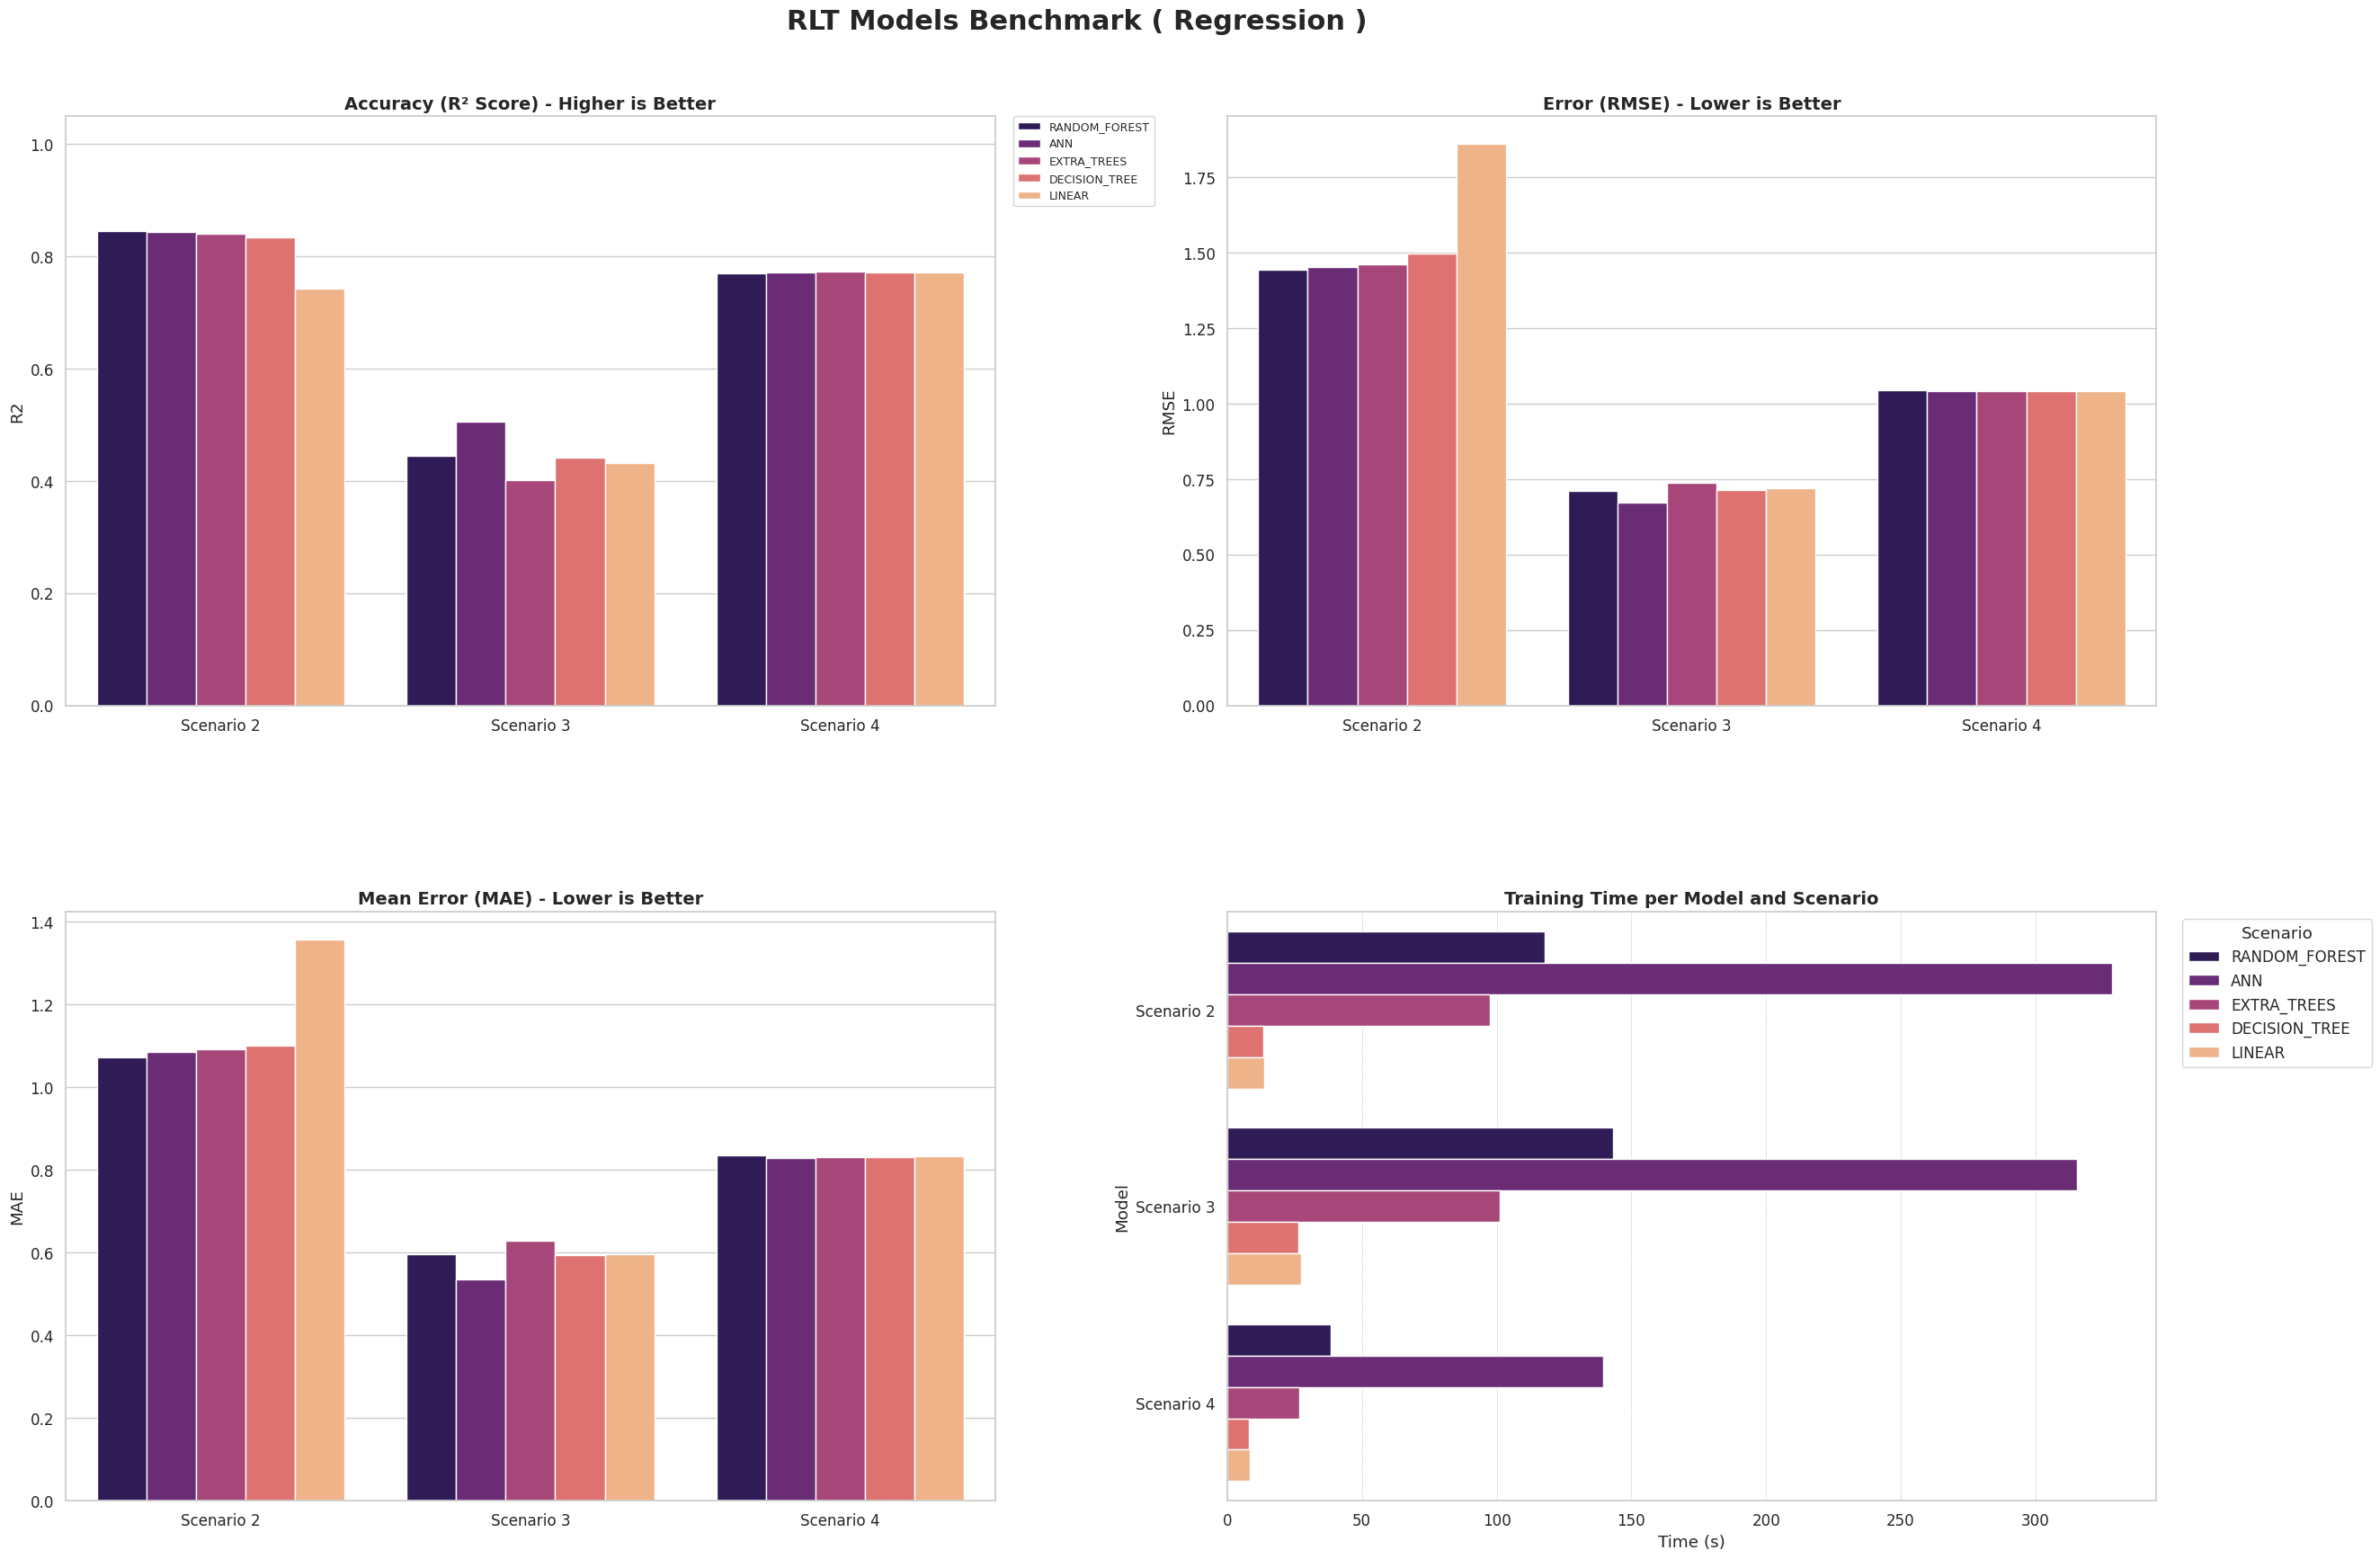

In [76]:
# ==============================================================================
#  1. LOAD DATA
# ==============================================================================
def load_data():
    try:
        # Load only the Standard Models CSV
        df = pd.read_csv("CSV/rlt_regression_metrics.csv")
        
        # RENAME 'Model' to 'Pilot Strategy' per your request
        df.rename(columns={'Model': 'Pilot Strategy'}, inplace=True)
        
        # Sort for better plotting consistency
        df.sort_values(by=['Scenario', 'R2'], ascending=[True, False], inplace=True)
        
        return df
    except FileNotFoundError:
        print("❌ Error: 'CSV/rlt_regression_metrics.csv not found.")
        return None

# ==============================================================================
#  2. PLOTTING FUNCTION
# ==============================================================================
def create_dashboard(df):
    # Set global theme
    sns.set_theme(style="whitegrid", font_scale=1.1)
    
    # Create 2x2 Grid
    fig, axes = plt.subplots(2, 2, figsize=(30, 20))
    plt.subplots_adjust(hspace=0.35, wspace=0.25)
    
    # Title
    fig.suptitle('RLT Models Benchmark ( Regression )', fontsize=22, weight='bold', y=0.94)

    # --- 1. R2 SCORE (Accuracy) ---
    ax1 = axes[0, 0]
    sns.barplot(
        data=df, 
        x='Scenario', 
        y='R2', 
        hue='Pilot Strategy', 
        palette='magma', 
        ax=ax1
    )
    ax1.set_title('Accuracy (R² Score) - Higher is Better', fontsize=14, weight='bold')
    ax1.set_ylim(0, 1.05)
    ax1.set_xlabel('')
    ax1.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0, fontsize=9)

    # --- 2. RMSE (Error) ---
    ax2 = axes[0, 1]
    sns.barplot(
        data=df, 
        x='Scenario', 
        y='RMSE', 
        hue='Pilot Strategy', 
        palette='magma', 
        ax=ax2
    )
    ax2.set_title('Error (RMSE) - Lower is Better', fontsize=14, weight='bold')
    ax2.set_xlabel('')
    ax2.legend().remove() # Remove legend (redundant)
    
    #3 --------------- MAE
    ax3 = axes[1, 0]
    sns.barplot(
        data=df, 
        x='Scenario', 
        y='MAE', 
        hue='Pilot Strategy', 
        palette='magma', 
        ax=ax3
    )
    ax3.set_title('Mean Error (MAE) - Lower is Better', fontsize=14, weight='bold')
    ax3.set_xlabel('')
    ax3.legend().remove() # Remove legend (redundant)

    # --- 3. EFFICIENCY FRONTIER (Time vs R2) ---
    
    

    ax4 = axes[1, 1]

    

    # Horizontal bar plot: models on y-axis, time on x-axis
    sns.barplot(
        data=df,
        y='Scenario',   # Models
        x='Time (s)',         # Training time
        hue='Pilot Strategy',       # Split by scenario
        palette='magma',
        ci=None,              # No confidence interval
        ax=ax4
    )

    ax4.set_title('Training Time per Model and Scenario', fontsize=14, weight='bold')
    ax4.set_xlabel('Time (s)')
    ax4.set_ylabel('Model')
    ax4.grid(True, axis='x', ls="--", linewidth=0.5)
    ax4.legend(title='Scenario', bbox_to_anchor=(1.02, 1), loc='upper left')

    # Save and Show
    filename = 'visualization/RLT_regression_metrics.png'
    plt.savefig(filename, bbox_inches='tight', dpi=300)
    print(f"✅ Dashboard saved to '{filename}'")
    plt.show()

# ==============================================================================
#  3. RUN
# ==============================================================================
if __name__ == "__main__":
    df = load_data()
    if df is not None:
        create_dashboard(df)

✅ Table saved as 'visualization/rlt_regression_winners_table.png'


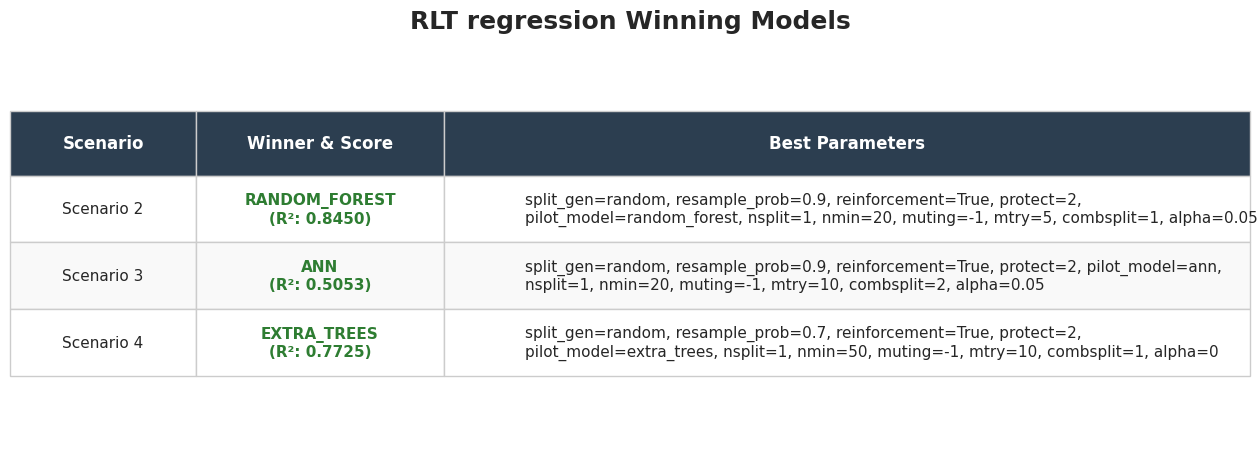

In [77]:
import pandas as pd
import matplotlib.pyplot as plt
import textwrap

# ==============================================================================
#  1. DATA PREPARATION
# ==============================================================================
def get_clean_winners():
    try:
        df = pd.read_csv("CSV/rlt_regression_metrics.csv")
    except FileNotFoundError:
        print("❌ Error: CSV file not found.")
        return None

    # Find Winners
    winner_indices = df.groupby('Scenario')['R2'].idxmax()
    winners = df.loc[winner_indices].copy()
    
    # Param columns
    param_cols = [c for c in df.columns if c.startswith('param_')]
    
    # Process each row
    table_data = []
    
    for _, row in winners.iterrows():
        # 1. Format Model & R2 (Col 2)
        # We combine them to save horizontal space: "XGBoost (0.95)"
        model_str = f"{row['Pilot Strategy']}\n(R²: {row['R2']:.4f})"
        
        # 2. Format Parameters (Col 3)
        valid_params = []
        for col in param_cols:
            val = row[col]
            if pd.notna(val) and str(val) != 'nan':
                key = col.replace('param_', '')
                # Format floats nicely
                val_str = f"{val:.4g}" if isinstance(val, float) else str(val)
                valid_params.append(f"{key}={val_str}")
        
        # Join and Wrap Text
        raw_param_str = ", ".join(valid_params)
        # Wrap text every 90 characters so it fits in the wide column
        wrapped_param_str = "\n".join(textwrap.wrap(raw_param_str, width=90))
        
        table_data.append([
            row['Scenario'], 
            model_str, 
            wrapped_param_str
        ])
        
    return pd.DataFrame(table_data, columns=["Scenario", "Winner & Score", "Best Parameters"])

# ==============================================================================
#  2. PLOTTING
# ==============================================================================
def plot_custom_table(df):
    if df is None: return

    # Adjust figure size based on content
    # Height = Header + (Rows * Height_Multiplier)
    fig_height = 2 + (len(df) * 1.2) 
    fig, ax = plt.subplots(figsize=(16, fig_height)) 
    
    ax.axis('off')

    # Define Column Widths (Sum should be close to 1.0)
    # Col 1 (Scenario): 15%
    # Col 2 (Model):    20%
    # Col 3 (Params):   65%
    widths = [0.15, 0.20, 0.65]

    # Create Table
    table = ax.table(
        cellText=df.values,
        colLabels=df.columns,
        cellLoc='left',
        loc='center',
        colWidths=widths
    )

    # Styling
    table.auto_set_font_size(False)
    table.set_fontsize(11)
    table.scale(1, 4) # Make rows taller to fit wrapped text

    # Apply specific styles to cells
    for (row, col), cell in table.get_celld().items():
        cell.set_edgecolor('#cccccc')
        cell.set_linewidth(1)
        
        # Header Row
        if row == 0:
            cell.set_text_props(weight='bold', color='white', size=12)
            cell.set_facecolor('#2c3e50') # Dark Blue/Grey
            cell.set_height(0.15)
            cell.set_text_props(horizontalalignment='center', verticalalignment='center')
        else:
            # Body Rows
            cell.set_text_props(verticalalignment='center')
            
            # Padding
            cell.set_text_props(horizontalalignment='left')
            
            # Alternating Row Colors
            if row % 2 == 0:
                cell.set_facecolor('#f9f9f9')
            else:
                cell.set_facecolor('#ffffff')

            # Center the Scenario and Model columns (0 and 1)
            if col in [0, 1]:
                cell.set_text_props(horizontalalignment='center')
                
            # Bold the Winner Name (Col 1)
            if col == 1:
                cell.set_text_props(weight='bold', color='#2e7d32') # Green

    plt.title("RLT regression Winning Models", fontsize=18, weight='bold', y=0.98)
    
    filename = "visualization/rlt_regression_winners_table.png"
    plt.savefig(filename, bbox_inches='tight', dpi=300)
    print(f"✅ Table saved as '{filename}'")
    plt.show()

# ==============================================================================
#  3. EXECUTION
# ==============================================================================
if __name__ == "__main__":
    df = get_clean_winners()
    plot_custom_table(df)

#### Classification

In [97]:
def calculate_classification_metrics(y_true, y_pred, model_name, params, training_time):
    """
    Calculates a comprehensive suite of classification metrics.
    Uses 'weighted' averages to handle potential class imbalance.
    """
    acc = accuracy_score(y_true, y_pred)
    bal_acc = balanced_accuracy_score(y_true, y_pred)
    
    # Weighted metrics handle multi-class and imbalance better than 'macro'
    f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    prec = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    
    # MCC is excellent for checking if the model is better than random guessing
    mcc = matthews_corrcoef(y_true, y_pred)
    
    return {
        "Pilot Strategy": model_name,
        "Accuracy": round(acc, 4),
        "Bal. Acc.": round(bal_acc, 4),
        "F1 (W)": round(f1, 4),
        "Precision": round(prec, 4),
        "Recall": round(rec, 4),
        "MCC": round(mcc, 4),
        "Time (s)": round(training_time, 4),
        "Best Params": params
    }

**Run Randomized search ( Classification )**

In [34]:
# ==============================================================================
#  SETUP
# ==============================================================================
# Define your classification scenarios here
scenarios_clf = {
    "Scenario 1 (Class)": (sc1_X, sc1_y),
}

# Master Dictionary
scenario_results_clf = {}


# ==============================================================================
#  MAIN LOOP
# ==============================================================================
for scenario_name, (X_curr, y_curr) in scenarios_clf.items():
    
    print("\n" + "#"*80)
    print(f" PROCESSING: {scenario_name}")
    print("#"*80)
    
    # 1. Initialize RLT for Classification
    rlt_clf = RLT(n_jobs=-1, model="classification", ntrees=50)

    # 2. Search (Optimizing for Accuracy)
    rs_clf = RandomizedSearchCV(
        estimator=rlt_clf,
        param_distributions=param_distributions,
        n_iter=n_iter_search,
        cv=cv_folds,
        verbose=0,
        n_jobs=-1,
        random_state=42,
        scoring='accuracy' 
    )
    
    total_fits = n_iter_search * cv_folds
    
    with tqdm_joblib(tqdm(desc=f"Searching {scenario_name}", total=total_fits, unit="fit")) as progress_bar:
        rs_clf.fit(X_curr, y_curr)


    # 3. Process Results
    df_results = pd.DataFrame(rs_clf.cv_results_)
    
    def get_group_name(row):
        if row['param_reinforcement'] is False:
            return "NO REINFORCEMENT"
        else:
            return str(row['param_pilot_model']).upper()

    df_results['model_group'] = df_results.apply(get_group_name, axis=1)

    # Find best indices per group
    best_indices = df_results.groupby('model_group')['mean_test_score'].idxmax()
    best_per_pilot_df = df_results.loc[best_indices].sort_values(by='mean_test_score', ascending=False).copy()
    
    # ==========================================================================
    #  CALCULATE FULL METRICS
    # ==========================================================================
    print("Benchmarking winners...")
    detailed_metrics_list = []
    
    for _, row in tqdm(best_per_pilot_df.iterrows(), total=len(best_per_pilot_df), desc="Benchmarking"):
        pilot_name = row['model_group']
        best_params = row['params']
        
        # Re-instantiate model
        winner_model = RLT(n_jobs=-1, model="classification", **best_params)
        
        # Cross-Val Predict to get clean test-like predictions
        start_time = time.time()
        y_cv_pred = cross_val_predict(winner_model, X_curr, y_curr, cv=cv_folds, n_jobs=-1)
        end_time = time.time()
        
        # Calculate Metrics
        metrics = calculate_classification_metrics(
            y_curr, 
            y_cv_pred, 
            pilot_name, 
            best_params,
            training_time=(end_time - start_time)
        )
        detailed_metrics_list.append(metrics)
        
    benchmarks_df = pd.DataFrame(detailed_metrics_list)
    
    # Identify Overall Best (by Accuracy)
    overall_best_row = benchmarks_df.loc[benchmarks_df['Accuracy'].idxmax()]
    
    # Store
    scenario_results_clf[scenario_name] = {
        "benchmarks_df": benchmarks_df,
        "overall_best_metrics": overall_best_row.to_dict(),
        "overall_best_params": overall_best_row["Best Params"],
        "raw_cv_results": df_results
    }

    # ==========================================================================
    #  DISPLAY RESULTS
    # ==========================================================================
    print(f"\n--- {scenario_name}: Detailed Benchmark ---")
    display_cols = [c for c in benchmarks_df.columns if c != "Best Params"]
    print(benchmarks_df[display_cols].to_string(index=False))
    
    print(f"\n >> OVERALL WINNER: {overall_best_row['Pilot Strategy']} (Acc: {overall_best_row['Accuracy']})")

print("\n" + "="*80)
print(" DONE. Results stored in 'scenario_results_clf'.")
print(" Access via: scenario_results_clf['Scenario 2 (Class)']['benchmarks_df']")
print("="*80)


################################################################################
 PROCESSING: Scenario 1 (Class)
################################################################################


Searching Scenario 1 (Class):   6%|██▉                                                | 23/400 [03:16<32:44,  5.21s/fit]/home/mohamed/RLT MOHH/.venv/lib/python3.12/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/mohamed/RLT MOHH/.venv/lib/python3.12/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/mohamed/RLT MOHH/.venv/lib/python3.12/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configurati

Benchmarking winners...


Benchmarking: 100%|██████████████████████████████████████████████████████████████████████| 5/5 [11:17<00:00, 135.50s/it]


--- Scenario 1 (Class): Detailed Benchmark ---
Pilot Strategy  Accuracy  Bal. Acc.  F1 (W)  Precision  Recall    MCC  Time (s)
 DECISION_TREE    0.5350     0.5346  0.5341     0.5349  0.5350 0.0695   26.6513
           ANN    0.5250     0.5246  0.5242     0.5248  0.5250 0.0494  376.9619
 RANDOM_FOREST    0.5155     0.5150  0.5142     0.5152  0.5155 0.0302  178.7492
   EXTRA_TREES    0.5220     0.5218  0.5217     0.5219  0.5220 0.0436   62.0657
        LINEAR    0.5210     0.5206  0.5198     0.5208  0.5210 0.0413   33.0519

 >> OVERALL WINNER: DECISION_TREE (Acc: 0.535)

 DONE. Results stored in 'scenario_results_clf'.
 Access via: scenario_results_clf['Scenario 2 (Class)']['benchmarks_df']


**Export to CSV**

In [78]:
import pandas as pd

# 1. Collect all dataframes from the dictionary
all_dfs = []

for scenario_name, result_data in scenario_results_clf.items():
    # Get the metrics dataframe
    df = result_data['benchmarks_df'].copy()
    
    # Add a column for the Scenario Name (so we know which rows belong to Sc2, Sc3, etc.)
    df.insert(0, 'Scenario', scenario_name)
    
    all_dfs.append(df)

# 2. Combine into one big DataFrame
final_df = pd.concat(all_dfs, ignore_index=True)

# 3. Flatten the "Best Params" dictionary into separate columns
# This turns {'ntrees': 50, 'alpha': 0.1} into columns: "param_ntrees", "param_alpha"
if 'Best Params' in final_df.columns:
    # Expand dictionary keys into columns
    params_expanded = final_df['Best Params'].apply(pd.Series).add_prefix('param_')
    
    # Join back to original data and drop the dictionary column
    final_df = pd.concat([final_df.drop(columns=['Best Params']), params_expanded], axis=1)

# 4. Save to CSV
output_filename = "CSV/rlt_classification_metrics.csv"
final_df.to_csv(output_filename, index=False)

print(f"✅ Success! Results saved to '{output_filename}'")
print(f"   Rows: {len(final_df)}")
print(f"   Columns: {list(final_df.columns)}")

✅ Success! Results saved to 'CSV/rlt_classification_metrics.csv'
   Rows: 5
   Columns: ['Scenario', 'Pilot Strategy', 'Accuracy', 'Bal. Acc.', 'F1 (W)', 'Precision', 'Recall', 'MCC', 'Time (s)', 'param_split_gen', 'param_resample_prob', 'param_reinforcement', 'param_protect', 'param_pilot_model', 'param_nsplit', 'param_nmin', 'param_muting', 'param_mtry', 'param_combsplit', 'param_alpha']


**Metrics ( RLT Classification )**

✅ Dashboard saved to 'visualization/RLT_classification_metrics.png'


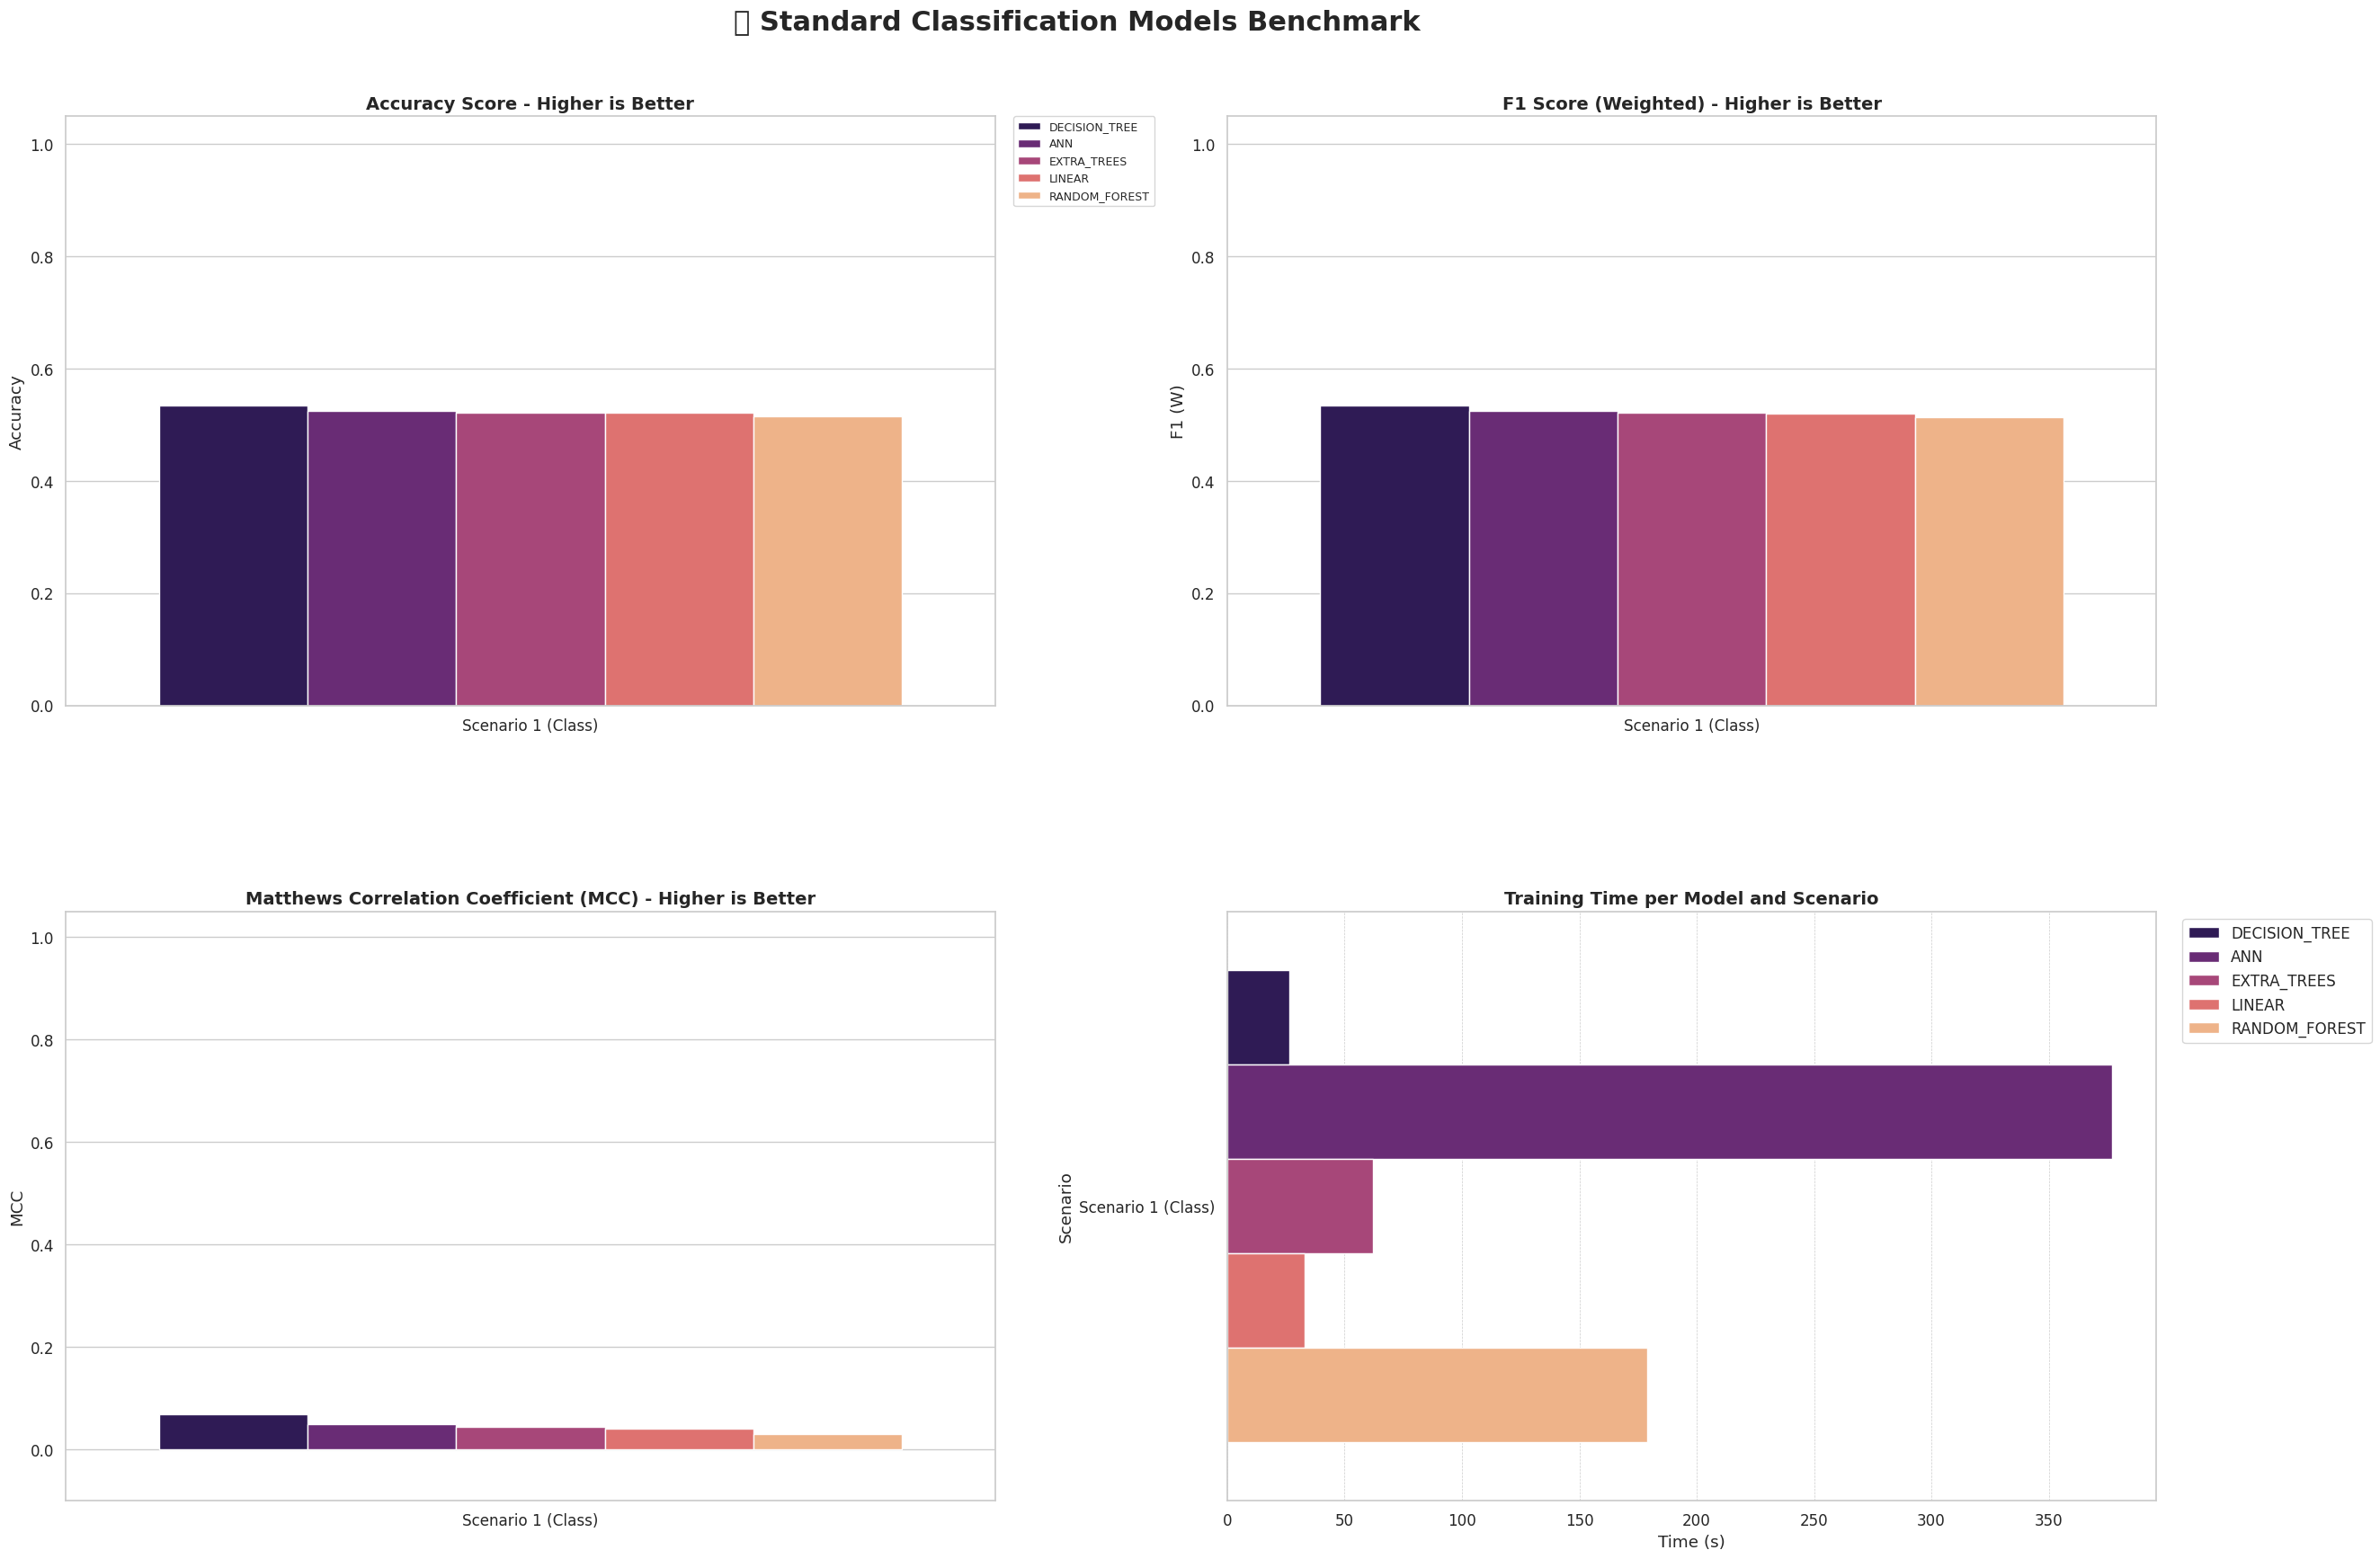

In [79]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ==============================================================================
#  1. LOAD DATA
# ==============================================================================
def load_data():
    try:
        # Load the Classification Benchmark CSV
        df = pd.read_csv("CSV/rlt_classification_metrics.csv")
        
        # RENAME 'Model' to 'Pilot Strategy' if needed (standardizing names)
        if 'Model' in df.columns:
            df.rename(columns={'Model': 'Pilot Strategy'}, inplace=True)
        
        # Sort by Scenario and Accuracy for better plotting consistency
        # We use Accuracy as the primary sorting metric here
        df.sort_values(by=['Scenario', 'Accuracy'], ascending=[True, False], inplace=True)
        
        return df
    except FileNotFoundError:
        print("❌ Error: 'CSV/rlt_classification_metrics.csv' not found.")
        return None

# ==============================================================================
#  2. PLOTTING FUNCTION
# ==============================================================================
def create_dashboard(df):
    # Set global theme
    sns.set_theme(style="whitegrid", font_scale=1.1)
    
    # Create 2x2 Grid
    fig, axes = plt.subplots(2, 2, figsize=(30, 20))
    plt.subplots_adjust(hspace=0.35, wspace=0.25)
    
    # Title
    fig.suptitle('📊 Standard Classification Models Benchmark', fontsize=22, weight='bold', y=0.94)

    # --- 1. ACCURACY ---
    ax1 = axes[0, 0]
    sns.barplot(
        data=df, 
        x='Scenario', 
        y='Accuracy', 
        hue='Pilot Strategy', 
        palette='magma', 
        ax=ax1
    )
    ax1.set_title('Accuracy Score - Higher is Better', fontsize=14, weight='bold')
    ax1.set_ylim(0, 1.05)
    ax1.set_xlabel('')
    ax1.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0, fontsize=9)

    # --- 2. F1 SCORE (Weighted) ---
    ax2 = axes[0, 1]
    sns.barplot(
        data=df, 
        x='Scenario', 
        y='F1 (W)', 
        hue='Pilot Strategy', 
        palette='magma', 
        ax=ax2
    )
    ax2.set_title('F1 Score (Weighted) - Higher is Better', fontsize=14, weight='bold')
    ax2.set_ylim(0, 1.05)
    ax2.set_xlabel('')
    ax2.legend().remove() # Remove legend (redundant)
    
    # --- 3. MCC (Matthews Correlation Coefficient) ---
    # MCC is often considered the most informative single metric
    ax3 = axes[1, 0]
    sns.barplot(
        data=df, 
        x='Scenario', 
        y='MCC', 
        hue='Pilot Strategy', 
        palette='magma', 
        ax=ax3
    )
    ax3.set_title('Matthews Correlation Coefficient (MCC) - Higher is Better', fontsize=14, weight='bold')
    ax3.set_xlabel('')
    # MCC can technically be negative, but usually 0 to 1 for decent models
    ax3.set_ylim(-0.1, 1.05) 
    ax3.legend().remove() 

    # --- 4. TRAINING TIME ---
    ax4 = axes[1, 1]
    sns.barplot(
        data=df,
        y='Scenario',         
        x='Time (s)',         
        hue='Pilot Strategy',       
        palette='magma',
        errorbar=None,              
        ax=ax4
    )

    ax4.set_title('Training Time per Model and Scenario', fontsize=14, weight='bold')
    ax4.set_xlabel('Time (s)')
    ax4.set_ylabel('Scenario')
    ax4.grid(True, axis='x', ls="--", linewidth=0.5)
    ax4.legend(bbox_to_anchor=(1.02, 1), loc='upper left')

    # Save and Show
    filename = 'visualization/RLT_classification_metrics.png'
    plt.savefig(filename, bbox_inches='tight', dpi=300)
    print(f"✅ Dashboard saved to '{filename}'")
    plt.show()

# ==============================================================================
#  3. RUN
# ==============================================================================
if __name__ == "__main__":
    df = load_data()
    if df is not None:
        create_dashboard(df)

✅ Table saved as 'visualization/rlt_classification_winners_table.png'


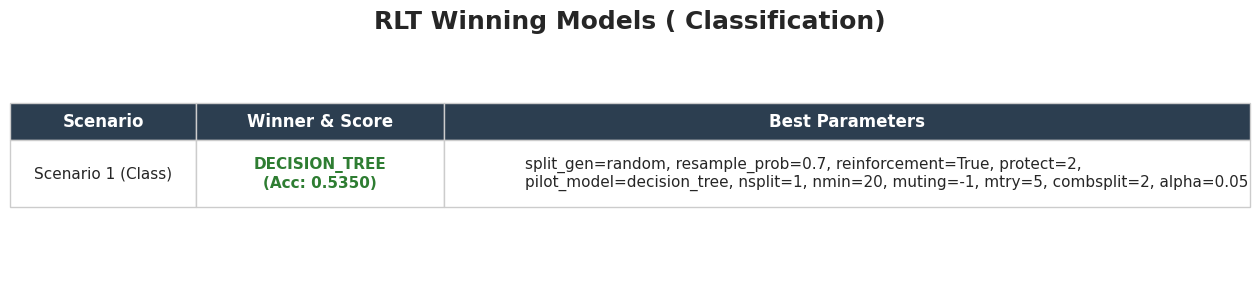

In [80]:
import pandas as pd
import matplotlib.pyplot as plt
import textwrap

# ==============================================================================
#  1. DATA PREPARATION (CLASSIFICATION VERSION)
# ==============================================================================
def get_clean_winners():
    try:
        # Load Classification CSV
        df = pd.read_csv("CSV/rlt_classification_metrics.csv")
    except FileNotFoundError:
        print("❌ Error: 'CSV/rlt_classification_metrics.csv not found.")
        return None

    # Find Winners based on ACCURACY
    # (You can change 'Accuracy' to 'F1 (W)' or 'MCC' if you prefer those metrics)
    winner_indices = df.groupby('Scenario')['Accuracy'].idxmax()
    winners = df.loc[winner_indices].copy()
    
    # Param columns
    param_cols = [c for c in df.columns if c.startswith('param_')]
    
    # Process each row
    table_data = []
    
    for _, row in winners.iterrows():
        # 1. Format Model & Accuracy (Col 2)
        # Display: "XGBoost\n(Acc: 0.9512)"
        model_str = f"{row['Pilot Strategy']}\n(Acc: {row['Accuracy']:.4f})"
        
        # 2. Format Parameters (Col 3)
        valid_params = []
        for col in param_cols:
            val = row[col]
            if pd.notna(val) and str(val) != 'nan':
                key = col.replace('param_', '')
                # Format floats nicely
                val_str = f"{val:.4g}" if isinstance(val, float) else str(val)
                valid_params.append(f"{key}={val_str}")
        
        # Join and Wrap Text
        raw_param_str = ", ".join(valid_params)
        # Wrap text every 90 characters so it fits in the wide column
        wrapped_param_str = "\n".join(textwrap.wrap(raw_param_str, width=90))
        
        table_data.append([
            row['Scenario'], 
            model_str, 
            wrapped_param_str
        ])
        
    return pd.DataFrame(table_data, columns=["Scenario", "Winner & Score", "Best Parameters"])

# ==============================================================================
#  2. PLOTTING
# ==============================================================================
def plot_custom_table(df):
    if df is None: return

    # Adjust figure size based on content
    # Height = Header + (Rows * Height_Multiplier)
    fig_height = 2 + (len(df) * 1.2) 
    fig, ax = plt.subplots(figsize=(16, fig_height)) 
    
    ax.axis('off')

    # Define Column Widths (Sum should be close to 1.0)
    # Col 1 (Scenario): 15%
    # Col 2 (Model):    20%
    # Col 3 (Params):   65%
    widths = [0.15, 0.20, 0.65]

    # Create Table
    table = ax.table(
        cellText=df.values,
        colLabels=df.columns,
        cellLoc='left',
        loc='center',
        colWidths=widths
    )

    # Styling
    table.auto_set_font_size(False)
    table.set_fontsize(11)
    table.scale(1, 4) # Make rows taller to fit wrapped text

    # Apply specific styles to cells
    for (row, col), cell in table.get_celld().items():
        cell.set_edgecolor('#cccccc')
        cell.set_linewidth(1)
        
        # Header Row
        if row == 0:
            cell.set_text_props(weight='bold', color='white', size=12)
            cell.set_facecolor('#2c3e50') # Dark Blue/Grey
            cell.set_height(0.15)
            cell.set_text_props(horizontalalignment='center', verticalalignment='center')
        else:
            # Body Rows
            cell.set_text_props(verticalalignment='center')
            cell.set_text_props(horizontalalignment='left')
            
            # Alternating Row Colors
            if row % 2 == 0:
                cell.set_facecolor('#f9f9f9')
            else:
                cell.set_facecolor('#ffffff')

            # Center the Scenario and Model columns (0 and 1)
            if col in [0, 1]:
                cell.set_text_props(horizontalalignment='center')
                
            # Bold the Winner Name (Col 1)
            if col == 1:
                cell.set_text_props(weight='bold', color='#2e7d32') # Green

    plt.title("RLT Winning Models ( Classification)", fontsize=18, weight='bold', y=0.98)
    
    filename = "visualization/rlt_classification_winners_table.png"
    plt.savefig(filename, bbox_inches='tight', dpi=300)
    print(f"✅ Table saved as '{filename}'")
    plt.show()

# ==============================================================================
#  3. EXECUTION
# ==============================================================================
if __name__ == "__main__":
    df = get_clean_winners()
    plot_custom_table(df)

# Base Models  

## Tuning External models 

#### **Grid :**

In [90]:
models_to_test = [
    (
        "Ridge Regression", 
        Ridge(), 
        {
            'alpha': [0.1, 1.0, 10.0]
        }
    ),
    (
        "Decision Tree", 
        DecisionTreeRegressor(random_state=42), 
        {
            'max_depth': [10, 20, None],
            'min_samples_leaf': [5, 10, 20]
        }
    ),
    (
        "Random Forest", 
        RandomForestRegressor(random_state=42, n_jobs=-1), 
        {
            'n_estimators': [100, 300],
            'max_depth': [None, 20], 
            'max_features': [1.0, 'sqrt'], 
            'min_samples_leaf': [1, 4]
        }
    ),
    (
        "Extra Trees", 
        ExtraTreesRegressor(random_state=42, n_jobs=-1), 
        {
            'n_estimators': [100, 300],
            'max_depth': [None, 20],
            'max_features': [1.0, 'sqrt'],
            'min_samples_leaf': [1, 4]
        }
    ),
    (
        "Gradient Boosting", 
        GradientBoostingRegressor(random_state=42), 
        {
            'n_estimators': [100, 300],
            'learning_rate': [0.05, 0.1],
            'max_depth': [3, 5],
            'subsample': [0.8, 1.0]
        }
    ),
    (
        "XGBoost", 
        XGBRegressor(random_state=42, n_jobs=-1, verbosity=0), 
        {
            'n_estimators': [100, 300],
            'learning_rate': [0.05, 0.1],
            'max_depth': [3, 6],
            'colsample_bytree': [0.7, 1.0],
            'subsample': [0.8, 1.0]
        }
    ),
    (
        "Neural Network (MLP)", 
        MLPRegressor(random_state=42, max_iter=500), 
        {
            'hidden_layer_sizes': [(100,), (100, 50)],
            'activation': ['relu'],
            'solver': ['adam','lbfgs'],
            'alpha': [0.0001, 0.01],
            'learning_rate_init': [0.001, 0.01]
        }
    )
]

### Regression

#### Randomized search

In [91]:
history_master = []
N_ITER_SEARCH = 20
SEARCH_CV = 3
FINAL_CV = 5

print(f"🚀 Starting Benchmark on {len(scenarios)} Scenarios with {len(models_to_test)} Models...")

for scenario_name, (X_curr, y_curr) in scenarios.items():
    print(f"\n📂 SCENARIO: {scenario_name}")
    
    scenario_best_score = -np.inf
    scenario_winner = "None"
    
    for model_name, model_inst, param_grid in tqdm(models_to_test, desc="Training"):
        
        # 1. Tuning
        search = RandomizedSearchCV(
            estimator=model_inst,
            param_distributions=param_grid,
            n_iter=N_ITER_SEARCH,
            scoring='r2',
            cv=SEARCH_CV,
            n_jobs=-1,
            random_state=42,
            verbose=0
        )
        
        try:
            search.fit(X_curr, y_curr)
        except Exception as e:
            print(f"Skipping {model_name}: {e}")
            continue
            
        # 2. Benchmark
        start_time = time.time()
        y_pred_cv = cross_val_predict(
            search.best_estimator_, 
            X_curr, 
            y_curr, 
            cv=FINAL_CV, 
            n_jobs=-1
        )
        training_time = time.time() - start_time
        
        # 3. Metrics
        metrics = calculate_detailed_metrics(
            y_curr, 
            y_pred_cv, 
            model_name,  # Passed correctly here
            search.best_params_,
            training_time
        )
        metrics['Scenario'] = scenario_name
        history_master.append(metrics)
        
        if metrics['R2'] > scenario_best_score:
            scenario_best_score = metrics['R2']
            scenario_winner = f"{model_name} (R2: {metrics['R2']})"

    print(f"🏆 Winner: {scenario_winner}")

🚀 Starting Benchmark on 3 Scenarios with 7 Models...

📂 SCENARIO: Scenario 2


Training: 100%|███████████████████████████████████████████████████████████████████████████| 7/7 [01:34<00:00, 13.45s/it]


🏆 Winner: Extra Trees (R2: 0.9133)

📂 SCENARIO: Scenario 3


Training: 100%|███████████████████████████████████████████████████████████████████████████| 7/7 [01:46<00:00, 15.27s/it]


🏆 Winner: XGBoost (R2: 0.9195)

📂 SCENARIO: Scenario 4


Training: 100%|███████████████████████████████████████████████████████████████████████████| 7/7 [01:20<00:00, 11.56s/it]

🏆 Winner: Ridge Regression (R2: 0.7833)


**Export to CSV**

In [92]:
print("\n💾 SAVING CSV...")
df_results = pd.DataFrame(history_master)

if 'Best Params' in df_results.columns:
    params_df = df_results['Best Params'].apply(pd.Series).add_prefix('param_')
    df_results = pd.concat([df_results.drop(columns=['Best Params']), params_df], axis=1)

# Ensure "Model" is in the column list
main_cols = ['Scenario', 'Pilot Strategy', 'R2', 'RMSE', 'MAE', 'MAPE (%)', 'MedAE', 'Max Error', 'Time (s)']
existing_main = [c for c in main_cols if c in df_results.columns]
param_cols = [c for c in df_results.columns if c.startswith('param_')]

df_final = df_results[existing_main + param_cols]
csv_filename = "CSV/base_models_regression_metrics.csv"
df_final.to_csv(csv_filename, index=False)

print(f"✅ Saved to {csv_filename}")
print(df_final[['Scenario', 'Pilot Strategy', 'R2']].head())


💾 SAVING CSV...
✅ Saved to CSV/base_models_regression_metrics.csv
     Scenario     Pilot Strategy      R2
0  Scenario 2   Ridge Regression  0.3135
1  Scenario 2      Decision Tree  0.8739
2  Scenario 2      Random Forest  0.9087
3  Scenario 2        Extra Trees  0.9133
4  Scenario 2  Gradient Boosting  0.9128


**Metrics : base Model ( Regression )**

✅ Dashboard saved to 'visualization/baseModels_regression_metrics.png'


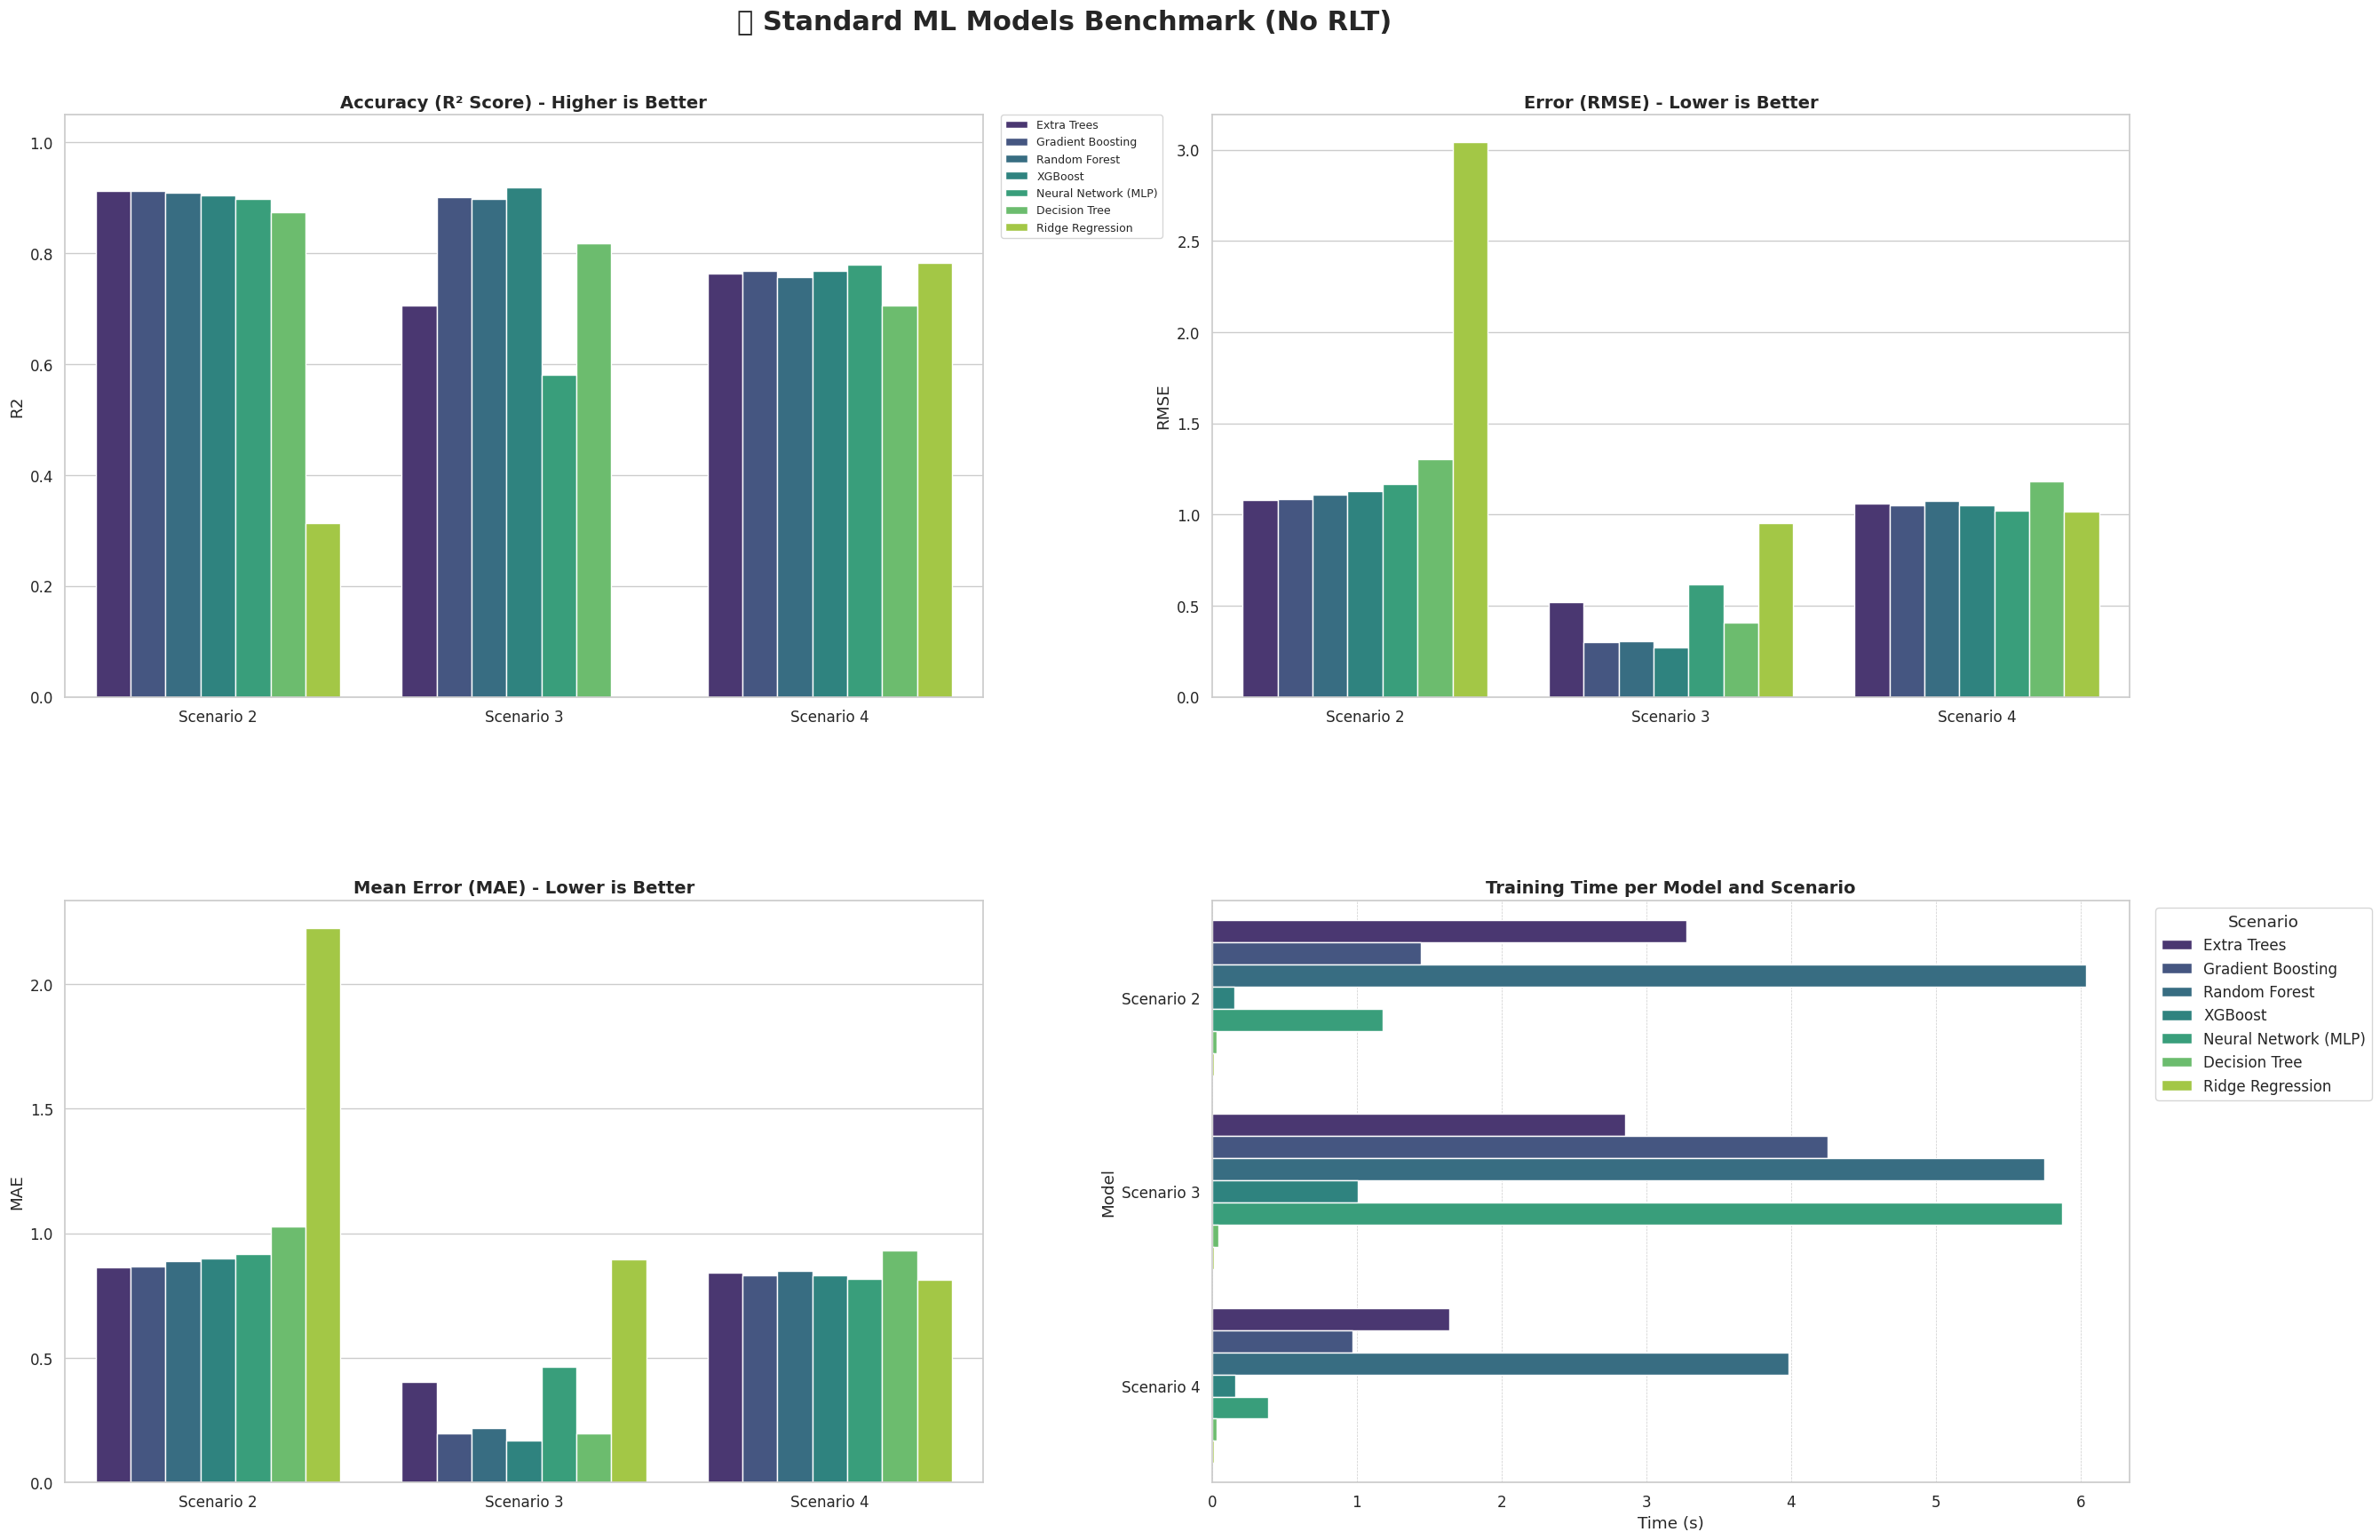

In [93]:
def load_data():
    try:
        # Load only the Standard Models CSV
        df = pd.read_csv("CSV/base_models_regression_metrics.csv")
        
        # RENAME 'Model' to 'Pilot Strategy' per your request
        df.rename(columns={'Model': 'Pilot Strategy'}, inplace=True)
        
        # Sort for better plotting consistency
        df.sort_values(by=['Scenario', 'R2'], ascending=[True, False], inplace=True)
        
        return df
    except FileNotFoundError:
        print("❌ Error: 'CSV/base_models_regression_metrics.csv' not found.")
        return None

# ==============================================================================
#  2. PLOTTING FUNCTION
# ==============================================================================
def create_dashboard(df):
    # Set global theme
    sns.set_theme(style="whitegrid", font_scale=1.1)
    
    # Create 2x2 Grid
    fig, axes = plt.subplots(2, 2, figsize=(30, 20))
    plt.subplots_adjust(hspace=0.35, wspace=0.25)
    
    # Title
    fig.suptitle('📊 Standard ML Models Benchmark (No RLT)', fontsize=22, weight='bold', y=0.94)

    # --- 1. R2 SCORE (Accuracy) ---
    ax1 = axes[0, 0]
    sns.barplot(
        data=df, 
        x='Scenario', 
        y='R2', 
        hue='Pilot Strategy', 
        palette='viridis', 
        ax=ax1
    )
    ax1.set_title('Accuracy (R² Score) - Higher is Better', fontsize=14, weight='bold')
    ax1.set_ylim(0, 1.05)
    ax1.set_xlabel('')
    ax1.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0, fontsize=9)

    # --- 2. RMSE (Error) ---
    ax2 = axes[0, 1]
    sns.barplot(
        data=df, 
        x='Scenario', 
        y='RMSE', 
        hue='Pilot Strategy', 
        palette='viridis', 
        ax=ax2
    )
    ax2.set_title('Error (RMSE) - Lower is Better', fontsize=14, weight='bold')
    ax2.set_xlabel('')
    ax2.legend().remove() # Remove legend (redundant)
    
    #3 --------------- MAE
    ax3 = axes[1, 0]
    sns.barplot(
        data=df, 
        x='Scenario', 
        y='MAE', 
        hue='Pilot Strategy', 
        palette='viridis', 
        ax=ax3
    )
    ax3.set_title('Mean Error (MAE) - Lower is Better', fontsize=14, weight='bold')
    ax3.set_xlabel('')
    ax3.legend().remove() # Remove legend (redundant)

    # --- 3. EFFICIENCY FRONTIER (Time vs R2) ---
    
    

    ax4 = axes[1, 1]

    

    # Horizontal bar plot: models on y-axis, time on x-axis
    sns.barplot(
        data=df,
        y='Scenario',   # Models
        x='Time (s)',         # Training time
        hue='Pilot Strategy',       # Split by scenario
        palette='viridis',
        ci=None,              # No confidence interval
        ax=ax4
    )

    ax4.set_title('Training Time per Model and Scenario', fontsize=14, weight='bold')
    ax4.set_xlabel('Time (s)')
    ax4.set_ylabel('Model')
    ax4.grid(True, axis='x', ls="--", linewidth=0.5)
    ax4.legend(title='Scenario', bbox_to_anchor=(1.02, 1), loc='upper left')

    # Save and Show
    filename = 'visualization/baseModels_regression_metrics.png'
    plt.savefig(filename, bbox_inches='tight', dpi=300)
    print(f"✅ Dashboard saved to '{filename}'")
    plt.show()

# ==============================================================================
#  3. RUN
# ==============================================================================
if __name__ == "__main__":
    df = load_data()
    if df is not None:
        create_dashboard(df)

✅ Table saved as 'visualization/baseModels_regression_winners_table.png'


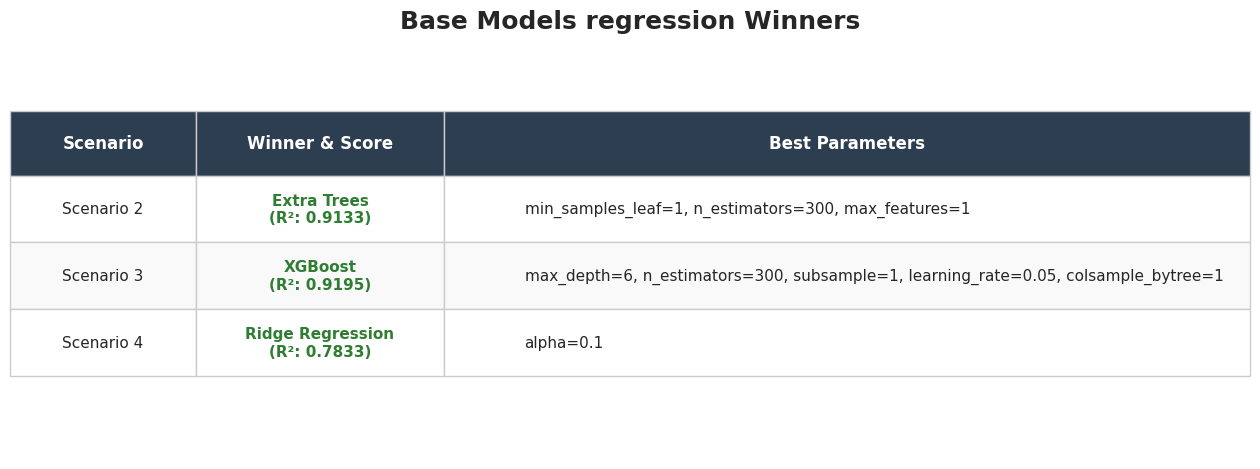

In [94]:
# ==============================================================================
#  1. DATA PREPARATION
# ==============================================================================
def get_clean_winners():
    try:
        df = pd.read_csv("CSV/base_models_regression_metrics.csv")
    except FileNotFoundError:
        print("❌ Error: CSV file not found.")
        return None

    # Find Winners
    winner_indices = df.groupby('Scenario')['R2'].idxmax()
    winners = df.loc[winner_indices].copy()
    
    # Param columns
    param_cols = [c for c in df.columns if c.startswith('param_')]
    
    # Process each row
    table_data = []
    
    for _, row in winners.iterrows():
        # 1. Format Model & R2 (Col 2)
        # We combine them to save horizontal space: "XGBoost (0.95)"
        model_str = f"{row['Pilot Strategy']}\n(R²: {row['R2']:.4f})"
        
        # 2. Format Parameters (Col 3)
        valid_params = []
        for col in param_cols:
            val = row[col]
            if pd.notna(val) and str(val) != 'nan':
                key = col.replace('param_', '')
                # Format floats nicely
                val_str = f"{val:.4g}" if isinstance(val, float) else str(val)
                valid_params.append(f"{key}={val_str}")
        
        # Join and Wrap Text
        raw_param_str = ", ".join(valid_params)
        # Wrap text every 90 characters so it fits in the wide column
        wrapped_param_str = "\n".join(textwrap.wrap(raw_param_str, width=90))
        
        table_data.append([
            row['Scenario'], 
            model_str, 
            wrapped_param_str
        ])
        
    return pd.DataFrame(table_data, columns=["Scenario", "Winner & Score", "Best Parameters"])

# ==============================================================================
#  2. PLOTTING
# ==============================================================================
def plot_custom_table(df):
    if df is None: return

    # Adjust figure size based on content
    # Height = Header + (Rows * Height_Multiplier)
    fig_height = 2 + (len(df) * 1.2) 
    fig, ax = plt.subplots(figsize=(16, fig_height)) 
    
    ax.axis('off')

    # Define Column Widths (Sum should be close to 1.0)
    # Col 1 (Scenario): 15%
    # Col 2 (Model):    20%
    # Col 3 (Params):   65%
    widths = [0.15, 0.20, 0.65]

    # Create Table
    table = ax.table(
        cellText=df.values,
        colLabels=df.columns,
        cellLoc='left',
        loc='center',
        colWidths=widths
    )

    # Styling
    table.auto_set_font_size(False)
    table.set_fontsize(11)
    table.scale(1, 4) # Make rows taller to fit wrapped text

    # Apply specific styles to cells
    for (row, col), cell in table.get_celld().items():
        cell.set_edgecolor('#cccccc')
        cell.set_linewidth(1)
        
        # Header Row
        if row == 0:
            cell.set_text_props(weight='bold', color='white', size=12)
            cell.set_facecolor('#2c3e50') # Dark Blue/Grey
            cell.set_height(0.15)
            cell.set_text_props(horizontalalignment='center', verticalalignment='center')
        else:
            # Body Rows
            cell.set_text_props(verticalalignment='center')
            
            # Padding
            cell.set_text_props(horizontalalignment='left')
            
            # Alternating Row Colors
            if row % 2 == 0:
                cell.set_facecolor('#f9f9f9')
            else:
                cell.set_facecolor('#ffffff')

            # Center the Scenario and Model columns (0 and 1)
            if col in [0, 1]:
                cell.set_text_props(horizontalalignment='center')
                
            # Bold the Winner Name (Col 1)
            if col == 1:
                cell.set_text_props(weight='bold', color='#2e7d32') # Green

    plt.title("Base Models regression Winners", fontsize=18, weight='bold', y=0.98)
    
    filename = "visualization/baseModels_regression_winners_table.png"
    plt.savefig(filename, bbox_inches='tight', dpi=300)
    print(f"✅ Table saved as '{filename}'")
    plt.show()

# ==============================================================================
#  3. EXECUTION
# ==============================================================================
if __name__ == "__main__":
    df = get_clean_winners()
    plot_custom_table(df)

### Classification

**Grid**

In [104]:
models_to_test = [
    (
        "Logistic Regression", 
        LogisticRegression(max_iter=1000, random_state=42), 
        {
            'C': [0.1, 1.0, 10.0, 100.0], 
            'solver': ['lbfgs', 'liblinear']
        }
    ),
    (
        "Decision Tree", 
        DecisionTreeClassifier(random_state=42), 
        {
            'criterion': ['gini', 'entropy'],
            'max_depth': [10, 20, None],
            'min_samples_leaf': [5, 10, 20]
        }
    ),
    (
        "Random Forest", 
        RandomForestClassifier(random_state=42, n_jobs=-1), 
        {
            'n_estimators': [100, 300],
            'max_depth': [None, 20], 
            'max_features': ['sqrt', 'log2'], 
            'min_samples_leaf': [1, 4]
        }
    ),
    (
        "Extra Trees", 
        ExtraTreesClassifier(random_state=42, n_jobs=-1), 
        {
            'n_estimators': [100, 300],
            'max_depth': [None, 20],
            'min_samples_leaf': [1, 4]
        }
    ),
    (
        "Gradient Boosting", 
        GradientBoostingClassifier(random_state=42), 
        {
            'n_estimators': [100, 300],
            'learning_rate': [0.05, 0.1],
            'max_depth': [3, 5],
            'subsample': [0.8, 1.0]
        }
    ),
    (
        "XGBoost", 
        XGBClassifier(random_state=42, n_jobs=-1, verbosity=0, use_label_encoder=False), 
        {
            'n_estimators': [100, 300],
            'learning_rate': [0.05, 0.1],
            'max_depth': [3, 6],
            'colsample_bytree': [0.7, 1.0],
            'subsample': [0.8, 1.0]
        }
    ),
    (
        "Neural Network (MLP)", 
        MLPClassifier(random_state=42, max_iter=500), 
        {
            'hidden_layer_sizes': [(100,), (100, 50)],
            'activation': ['relu'],
            'solver': ['adam', 'lbfgs'], 
            'alpha': [0.0001, 0.01],
            'learning_rate_init': [0.001, 0.01]
        }
    )
]

**Run**

In [105]:
# Suppress warnings
warnings.filterwarnings('ignore')

# ==============================================================================
#  3. MAIN BENCHMARK LOOP
# ==============================================================================

history_master = []
N_ITER_SEARCH = 50
SEARCH_CV = 3
FINAL_CV = 5
scenarios_clf = {
    "Scenario 1 (Class)": (sc1_X, sc1_y),
}

print(f"🚀 Starting CLASSIFICATION Benchmark on {len(scenarios)} Scenarios...")

for scenario_name, (sc1_X, sc1_y) in scenarios_clf.items():
    print(f"\n📂 SCENARIO: {scenario_name}")
    
    scenario_best_score = 0.0
    scenario_winner = "None"
    
    for model_name, model_inst, param_grid in tqdm(models_to_test, desc="Training"):
        
        # 1. Randomized Search
        search = RandomizedSearchCV(
            estimator=model_inst,
            param_distributions=param_grid,
            n_iter=N_ITER_SEARCH,
            scoring='accuracy', 
            cv=SEARCH_CV,
            n_jobs=-1,
            random_state=42,
            verbose=0
        )
        
        try:
            search.fit(X_curr, y_curr)
        except Exception as e:
            print(f"Skipping {model_name}: {e}")
            continue
            
        # 2. Benchmark Best Model
        start_time = time.time()
        y_pred_cv = cross_val_predict(
            search.best_estimator_, 
            X_curr, 
            y_curr, 
            cv=FINAL_CV, 
            n_jobs=-1
        )
        training_time = time.time() - start_time
        
        # 3. Calculate Metrics (Using your custom function)
        metrics = calculate_classification_metrics(
            y_curr, 
            y_pred_cv, 
            model_name, 
            search.best_params_,
            training_time
        )
        metrics['Scenario'] = scenario_name
        history_master.append(metrics)
        
        # Track Winner (by Accuracy)
        if metrics['Accuracy'] > scenario_best_score:
            scenario_best_score = metrics['Accuracy']
            scenario_winner = f"{model_name} (Acc: {metrics['Accuracy']:.4f})"

    print(f"🏆 Winner: {scenario_winner}")

🚀 Starting CLASSIFICATION Benchmark on 3 Scenarios...

📂 SCENARIO: Scenario 1 (Class)


Training: 100%|███████████████████████████████████████████████████████████████████████████| 7/7 [01:26<00:00, 12.38s/it]

🏆 Winner: XGBoost (Acc: 0.6065)


**Export to CSV**

In [106]:
print("\n💾 PROCESSING RESULTS & SAVING CSV...")
df_results = pd.DataFrame(history_master)

# Expand "Best Params" dictionary into columns
if 'Best Params' in df_results.columns:
    params_df = df_results['Best Params'].apply(pd.Series).add_prefix('param_')
    df_results = pd.concat([df_results.drop(columns=['Best Params']), params_df], axis=1)

# Define column order matching your metrics function keys
# Note: "Pilot Strategy" is used here because your function returns that key
main_cols = [
    'Scenario', 'Pilot Strategy', 
    'Accuracy', 'Bal. Acc.', 'F1 (W)', 'Precision', 'Recall', 'MCC', 
    'Time (s)'
]

# Ensure columns exist before selecting
existing_main = [c for c in main_cols if c in df_results.columns]
param_cols = [c for c in df_results.columns if c.startswith('param_')]

df_final = df_results[existing_main + param_cols]

csv_filename = "CSV/baseModels_classification_metrics.csv"
df_final.to_csv(csv_filename, index=False)

print(f"✅ Saved to {csv_filename}")
print(df_final[['Scenario', 'Pilot Strategy', 'Accuracy', 'MCC']].head())


💾 PROCESSING RESULTS & SAVING CSV...
✅ Saved to CSV/baseModels_classification_metrics.csv
             Scenario       Pilot Strategy  Accuracy     MCC
0  Scenario 1 (Class)  Logistic Regression    0.5045  0.0077
1  Scenario 1 (Class)        Decision Tree    0.5115  0.0225
2  Scenario 1 (Class)        Random Forest    0.5515  0.1028
3  Scenario 1 (Class)          Extra Trees    0.5420  0.0836
4  Scenario 1 (Class)    Gradient Boosting    0.6035  0.2069


**Metrics Comparison**

✅ Dashboard saved to 'visualization/baseModels_classification_metrics.png'


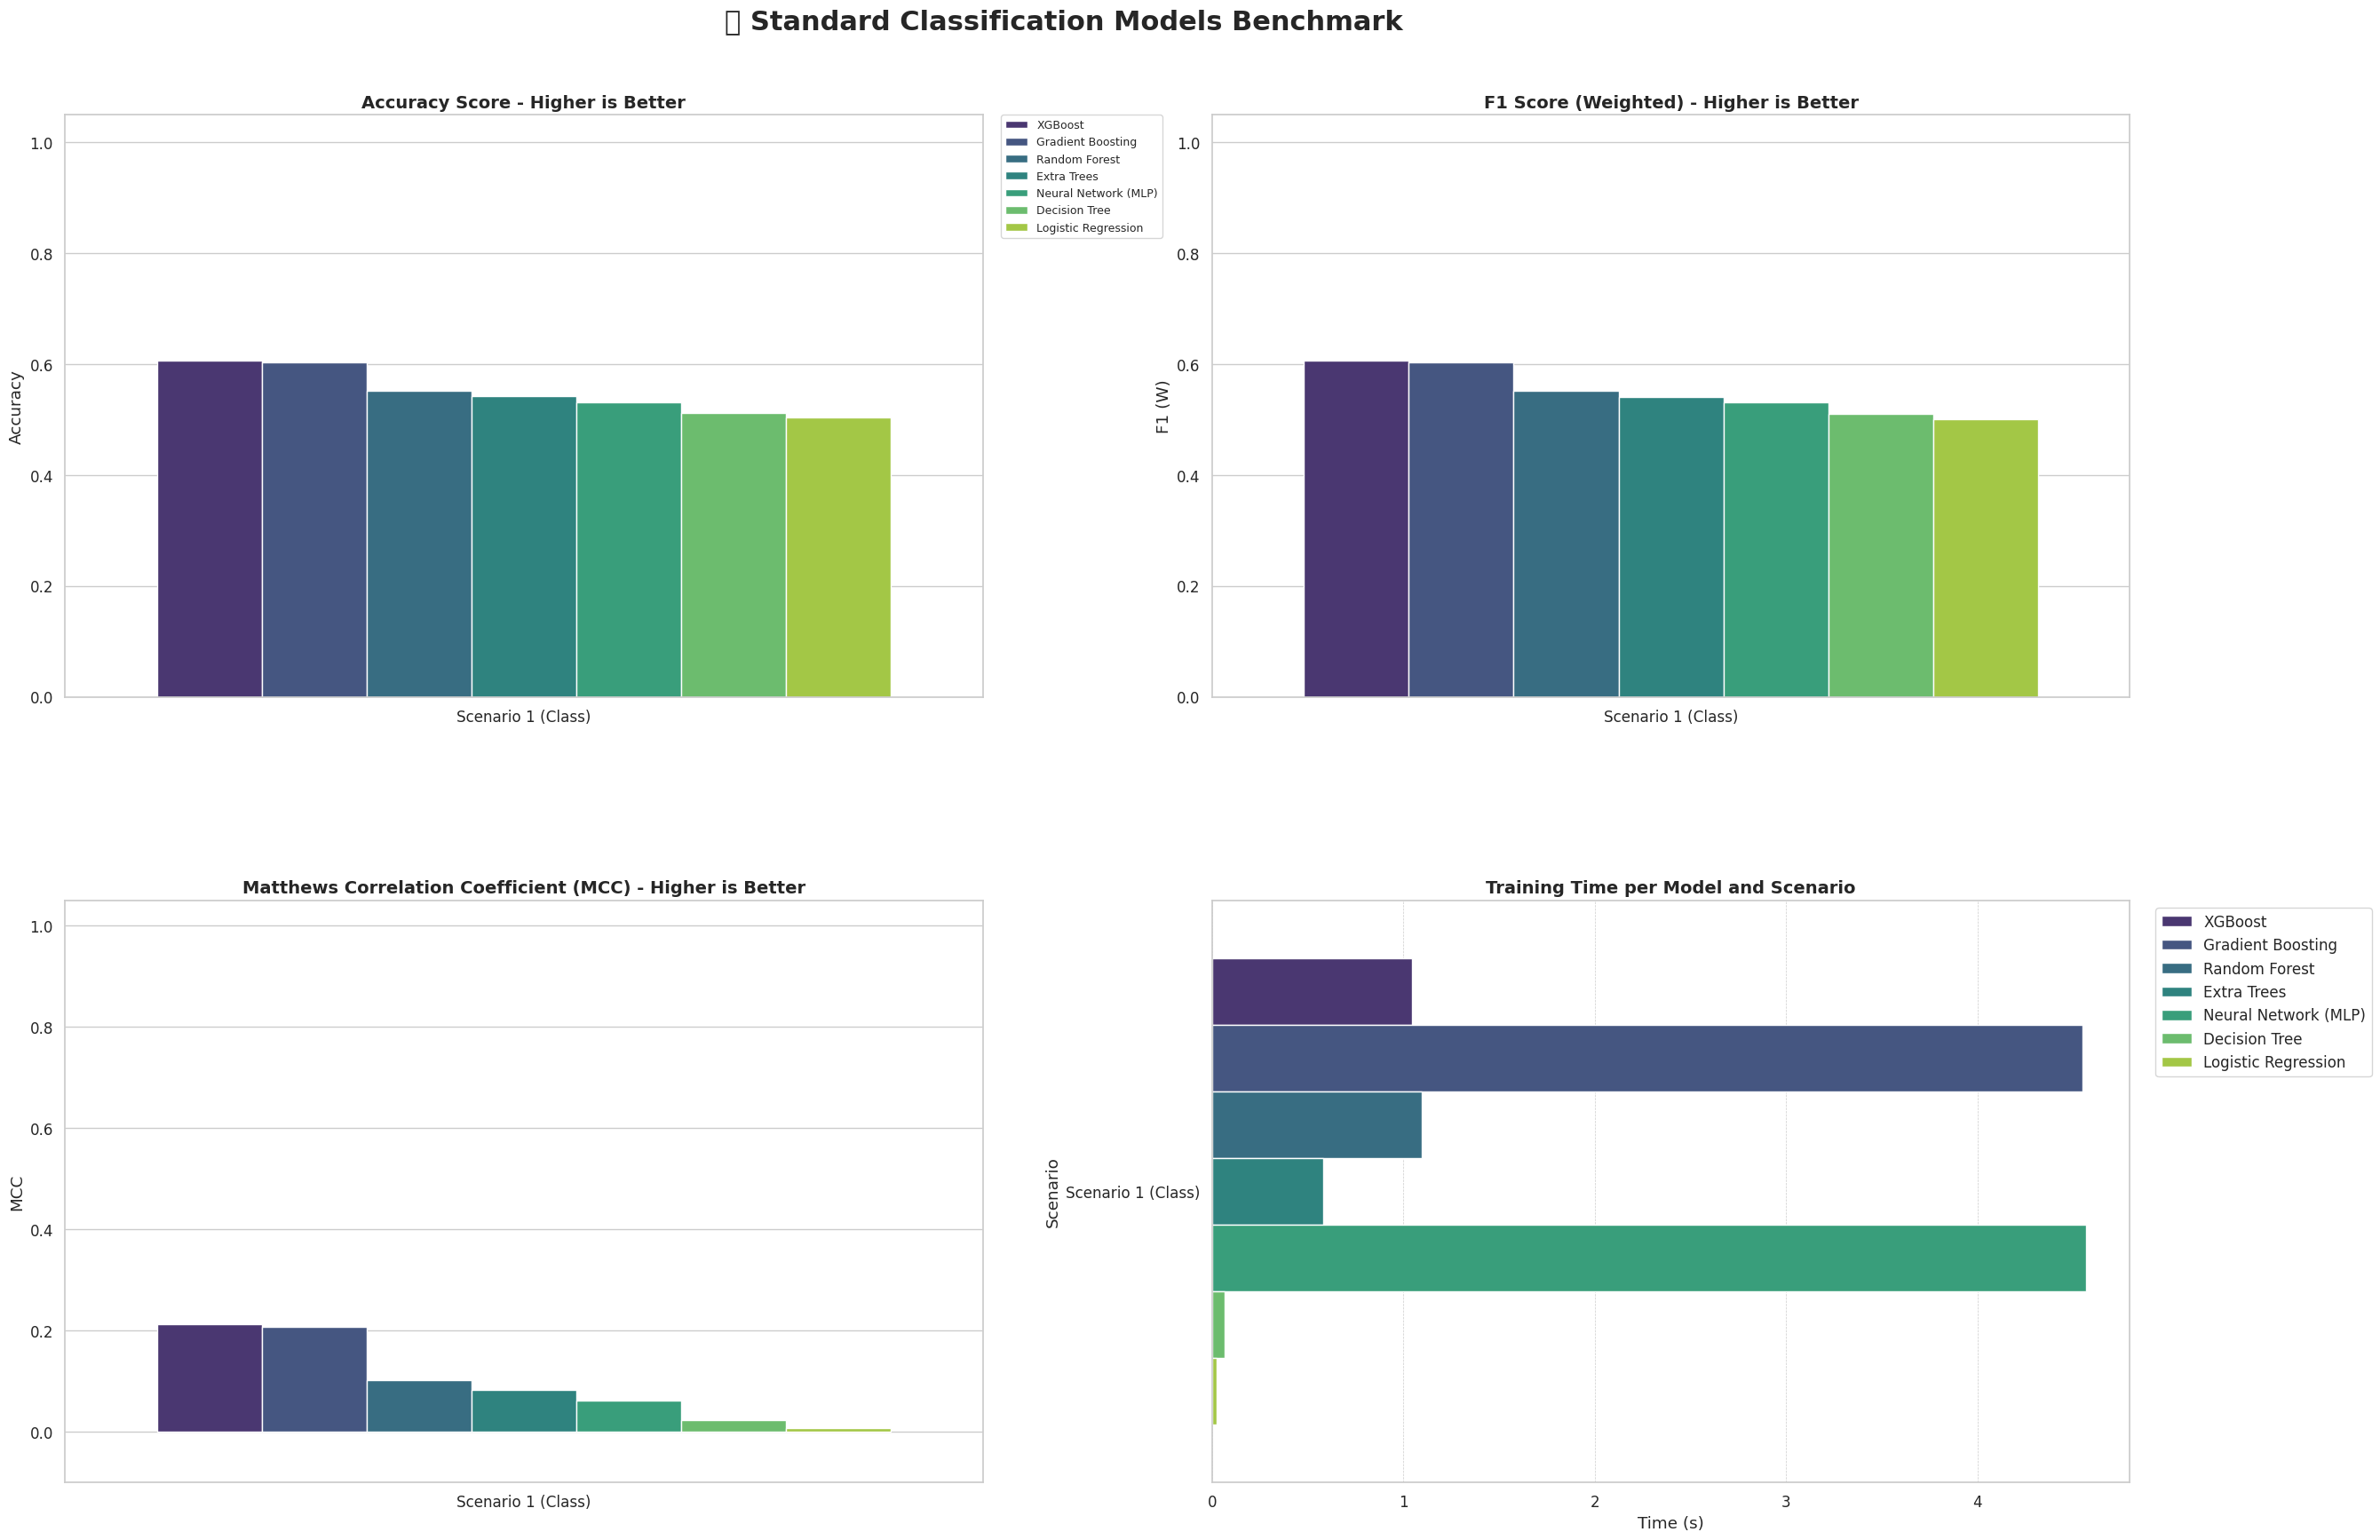

In [107]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ==============================================================================
#  1. LOAD DATA
# ==============================================================================
def load_data():
    try:
        # Load the Classification Benchmark CSV
        df = pd.read_csv("CSV/baseModels_classification_metrics.csv")
        
        # RENAME 'Model' to 'Pilot Strategy' if needed (standardizing names)
        if 'Model' in df.columns:
            df.rename(columns={'Model': 'Pilot Strategy'}, inplace=True)
        
        # Sort by Scenario and Accuracy for better plotting consistency
        # We use Accuracy as the primary sorting metric here
        df.sort_values(by=['Scenario', 'Accuracy'], ascending=[True, False], inplace=True)
        
        return df
    except FileNotFoundError:
        print("❌ Error: 'CSV/baseModels_classification_metrics.csv' not found.")
        return None

# ==============================================================================
#  2. PLOTTING FUNCTION
# ==============================================================================
def create_dashboard(df):
    # Set global theme
    sns.set_theme(style="whitegrid", font_scale=1.1)
    
    # Create 2x2 Grid
    fig, axes = plt.subplots(2, 2, figsize=(30, 20))
    plt.subplots_adjust(hspace=0.35, wspace=0.25)
    
    # Title
    fig.suptitle('📊 Standard Classification Models Benchmark', fontsize=22, weight='bold', y=0.94)

    # --- 1. ACCURACY ---
    ax1 = axes[0, 0]
    sns.barplot(
        data=df, 
        x='Scenario', 
        y='Accuracy', 
        hue='Pilot Strategy', 
        palette='viridis', 
        ax=ax1
    )
    ax1.set_title('Accuracy Score - Higher is Better', fontsize=14, weight='bold')
    ax1.set_ylim(0, 1.05)
    ax1.set_xlabel('')
    ax1.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0, fontsize=9)

    # --- 2. F1 SCORE (Weighted) ---
    ax2 = axes[0, 1]
    sns.barplot(
        data=df, 
        x='Scenario', 
        y='F1 (W)', 
        hue='Pilot Strategy', 
        palette='viridis', 
        ax=ax2
    )
    ax2.set_title('F1 Score (Weighted) - Higher is Better', fontsize=14, weight='bold')
    ax2.set_ylim(0, 1.05)
    ax2.set_xlabel('')
    ax2.legend().remove() # Remove legend (redundant)
    
    # --- 3. MCC (Matthews Correlation Coefficient) ---
    # MCC is often considered the most informative single metric
    ax3 = axes[1, 0]
    sns.barplot(
        data=df, 
        x='Scenario', 
        y='MCC', 
        hue='Pilot Strategy', 
        palette='viridis', 
        ax=ax3
    )
    ax3.set_title('Matthews Correlation Coefficient (MCC) - Higher is Better', fontsize=14, weight='bold')
    ax3.set_xlabel('')
    # MCC can technically be negative, but usually 0 to 1 for decent models
    ax3.set_ylim(-0.1, 1.05) 
    ax3.legend().remove() 

    # --- 4. TRAINING TIME ---
    ax4 = axes[1, 1]
    sns.barplot(
        data=df,
        y='Scenario',         
        x='Time (s)',         
        hue='Pilot Strategy',       
        palette='viridis',
        errorbar=None,              
        ax=ax4
    )

    ax4.set_title('Training Time per Model and Scenario', fontsize=14, weight='bold')
    ax4.set_xlabel('Time (s)')
    ax4.set_ylabel('Scenario')
    ax4.grid(True, axis='x', ls="--", linewidth=0.5)
    ax4.legend(bbox_to_anchor=(1.02, 1), loc='upper left')

    # Save and Show
    filename = 'visualization/baseModels_classification_metrics.png'
    plt.savefig(filename, bbox_inches='tight', dpi=300)
    print(f"✅ Dashboard saved to '{filename}'")
    plt.show()

# ==============================================================================
#  3. RUN
# ==============================================================================
if __name__ == "__main__":
    df = load_data()
    if df is not None:
        create_dashboard(df)

✅ Table saved as 'visualization/baseModels_classification_winners_table.png'


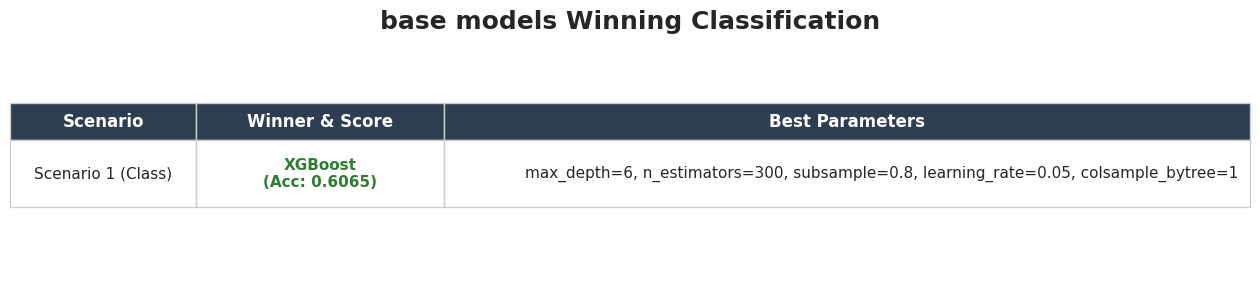

In [108]:
import pandas as pd
import matplotlib.pyplot as plt
import textwrap

# ==============================================================================
#  1. DATA PREPARATION (CLASSIFICATION VERSION)
# ==============================================================================
def get_clean_winners():
    try:
        # Load Classification CSV
        df = pd.read_csv("CSV/baseModels_classification_metrics.csv")
    except FileNotFoundError:
        print("❌ Error: 'CSV/baseModels_classification_metrics.csv' not found.")
        return None

    # Find Winners based on ACCURACY
    # (You can change 'Accuracy' to 'F1 (W)' or 'MCC' if you prefer those metrics)
    winner_indices = df.groupby('Scenario')['Accuracy'].idxmax()
    winners = df.loc[winner_indices].copy()
    
    # Param columns
    param_cols = [c for c in df.columns if c.startswith('param_')]
    
    # Process each row
    table_data = []
    
    for _, row in winners.iterrows():
        # 1. Format Model & Accuracy (Col 2)
        # Display: "XGBoost\n(Acc: 0.9512)"
        model_str = f"{row['Pilot Strategy']}\n(Acc: {row['Accuracy']:.4f})"
        
        # 2. Format Parameters (Col 3)
        valid_params = []
        for col in param_cols:
            val = row[col]
            if pd.notna(val) and str(val) != 'nan':
                key = col.replace('param_', '')
                # Format floats nicely
                val_str = f"{val:.4g}" if isinstance(val, float) else str(val)
                valid_params.append(f"{key}={val_str}")
        
        # Join and Wrap Text
        raw_param_str = ", ".join(valid_params)
        # Wrap text every 90 characters so it fits in the wide column
        wrapped_param_str = "\n".join(textwrap.wrap(raw_param_str, width=90))
        
        table_data.append([
            row['Scenario'], 
            model_str, 
            wrapped_param_str
        ])
        
    return pd.DataFrame(table_data, columns=["Scenario", "Winner & Score", "Best Parameters"])

# ==============================================================================
#  2. PLOTTING
# ==============================================================================
def plot_custom_table(df):
    if df is None: return

    # Adjust figure size based on content
    # Height = Header + (Rows * Height_Multiplier)
    fig_height = 2 + (len(df) * 1.2) 
    fig, ax = plt.subplots(figsize=(16, fig_height)) 
    
    ax.axis('off')

    # Define Column Widths (Sum should be close to 1.0)
    # Col 1 (Scenario): 15%
    # Col 2 (Model):    20%
    # Col 3 (Params):   65%
    widths = [0.15, 0.20, 0.65]

    # Create Table
    table = ax.table(
        cellText=df.values,
        colLabels=df.columns,
        cellLoc='left',
        loc='center',
        colWidths=widths
    )

    # Styling
    table.auto_set_font_size(False)
    table.set_fontsize(11)
    table.scale(1, 4) # Make rows taller to fit wrapped text

    # Apply specific styles to cells
    for (row, col), cell in table.get_celld().items():
        cell.set_edgecolor('#cccccc')
        cell.set_linewidth(1)
        
        # Header Row
        if row == 0:
            cell.set_text_props(weight='bold', color='white', size=12)
            cell.set_facecolor('#2c3e50') # Dark Blue/Grey
            cell.set_height(0.15)
            cell.set_text_props(horizontalalignment='center', verticalalignment='center')
        else:
            # Body Rows
            cell.set_text_props(verticalalignment='center')
            cell.set_text_props(horizontalalignment='left')
            
            # Alternating Row Colors
            if row % 2 == 0:
                cell.set_facecolor('#f9f9f9')
            else:
                cell.set_facecolor('#ffffff')

            # Center the Scenario and Model columns (0 and 1)
            if col in [0, 1]:
                cell.set_text_props(horizontalalignment='center')
                
            # Bold the Winner Name (Col 1)
            if col == 1:
                cell.set_text_props(weight='bold', color='#2e7d32') # Green

    plt.title("base models Winning Classification", fontsize=18, weight='bold', y=0.98)
    
    filename = "visualization/baseModels_classification_winners_table.png"
    plt.savefig(filename, bbox_inches='tight', dpi=300)
    print(f"✅ Table saved as '{filename}'")
    plt.show()

# ==============================================================================
#  3. EXECUTION
# ==============================================================================
if __name__ == "__main__":
    df = get_clean_winners()
    plot_custom_table(df)

# Benchmark ( RLT VS BaseModels )

## Regression
**we will take the best RLT that performed in both scenarios and compare it with the best base model performence**